In [1]:
# -----------------------------------------------------------
# 1. Download (or re-use) the dataset and get its root folder
# -----------------------------------------------------------
import kagglehub
from pathlib import Path
import pandas as pd
from PIL import Image

# This returns the local cache path
dataset_root = Path(
    kagglehub.dataset_download(
        "mohamedgobara/oral-lesions-malignancy-detection-dataset"
    )
)
print(f"✔ Dataset cached at: {dataset_root}")

# -----------------------------------------------------------
# 2. Point to the two class folders you want to use
#    (original_data vs augmented_data — pick whichever you need)
# -----------------------------------------------------------
# ⚠️ Change this to "original_data" if you prefer the non-augmented images
SUBFOLDER = "augmented_data"

benign_dir    = dataset_root / "Oral Images Dataset" / SUBFOLDER / "augmented_benign"
malignant_dir = dataset_root / "Oral Images Dataset" / SUBFOLDER / "augmented_malignant"

for d in (benign_dir, malignant_dir):
    if not d.exists():
        raise FileNotFoundError(f"Expected directory not found → {d}")

# -----------------------------------------------------------
# 3. Helper: check if a file is a valid image
# -----------------------------------------------------------
def is_image(fp):
    try:
        Image.open(fp).verify()
        return True
    except Exception:
        return False

# -----------------------------------------------------------
# 4. Build a dataframe of filepaths + labels
# -----------------------------------------------------------
filepaths, labels = [], []
class_map = [(benign_dir,    "Oral lesions benign"),
             (malignant_dir, "Oral lesions malignant")]

for folder, label in class_map:
    for fp in folder.iterdir():
        if fp.is_file() and is_image(fp):
            filepaths.append(str(fp))
            labels.append(label)

oral_df = pd.DataFrame({"filepaths": filepaths, "labels": labels})
print(oral_df.head(3))
print("\nClass counts:\n", oral_df["labels"].value_counts())


✔ Dataset cached at: /kaggle/input/datasets/mohamedgobara/oral-lesions-malignancy-detection-dataset
                                           filepaths               labels
0  /kaggle/input/datasets/mohamedgobara/oral-lesi...  Oral lesions benign
1  /kaggle/input/datasets/mohamedgobara/oral-lesi...  Oral lesions benign
2  /kaggle/input/datasets/mohamedgobara/oral-lesi...  Oral lesions benign

Class counts:
 labels
Oral lesions benign       1155
Oral lesions malignant    1115
Name: count, dtype: int64


In [2]:
import pandas as pd
import numpy as np
import keras
import warnings
warnings.filterwarnings(action="ignore")
import matplotlib.pyplot as plt
%matplotlib inline

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

from tensorflow.keras.callbacks import TensorBoard,EarlyStopping

import sklearn.metrics as metrics
from keras.callbacks import LearningRateScheduler

# annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x, verbose=0)

2026-04-21 08:32:33.617742: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776760353.813817      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776760353.875379      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776760354.365051      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776760354.365091      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776760354.365094      55 computation_placer.cc:177] computation placer alr

In [3]:
oral_df.shape

(2270, 2)

In [4]:
train_images, test_images = train_test_split(oral_df, test_size=0.3, random_state=42)
train_set, val_set = train_test_split(oral_df, test_size=0.2, random_state=42)

In [5]:
print(train_set.shape)
print(test_images.shape)
print(val_set.shape)
print(train_images.shape)

(1816, 2)
(681, 2)
(454, 2)
(1589, 2)


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_gen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train = image_gen.flow_from_dataframe(
    dataframe=train_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(224, 224),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=4,
    shuffle=True,
    seed=42
)

val = image_gen.flow_from_dataframe(
    dataframe=val_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(224, 224),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=4,
    shuffle=False
)

test = image_gen.flow_from_dataframe(
    dataframe=test_images,
    x_col="filepaths",
    y_col="labels",
    target_size=(224, 224),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=4,
    shuffle=False
)


Found 1816 validated image filenames belonging to 2 classes.
Found 454 validated image filenames belonging to 2 classes.
Found 681 validated image filenames belonging to 2 classes.


In [7]:
classes=list(train.class_indices.keys())
print (classes)

['Oral lesions benign', 'Oral lesions malignant']


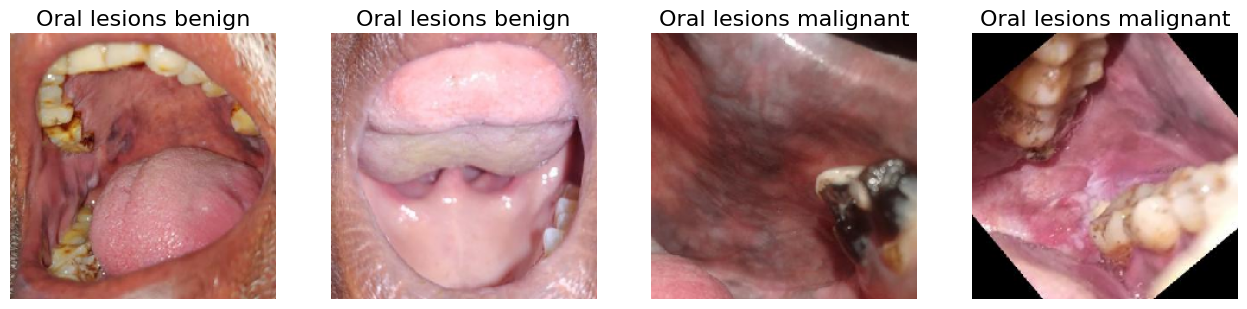

In [8]:
def show_knee_images(image_gen):
    test_dict = test.class_indices
    classes = list(test_dict.keys())
    images, labels=next(image_gen) # get a sample batch from the generator
    plt.figure(figsize=(20,20))
    length = len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5,5,i+1)
        image=(images[i]+1)/2 #scale images between 0 and 1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name,fontsize=16)
        plt.axis('off')
    plt.show()
show_knee_images(train)

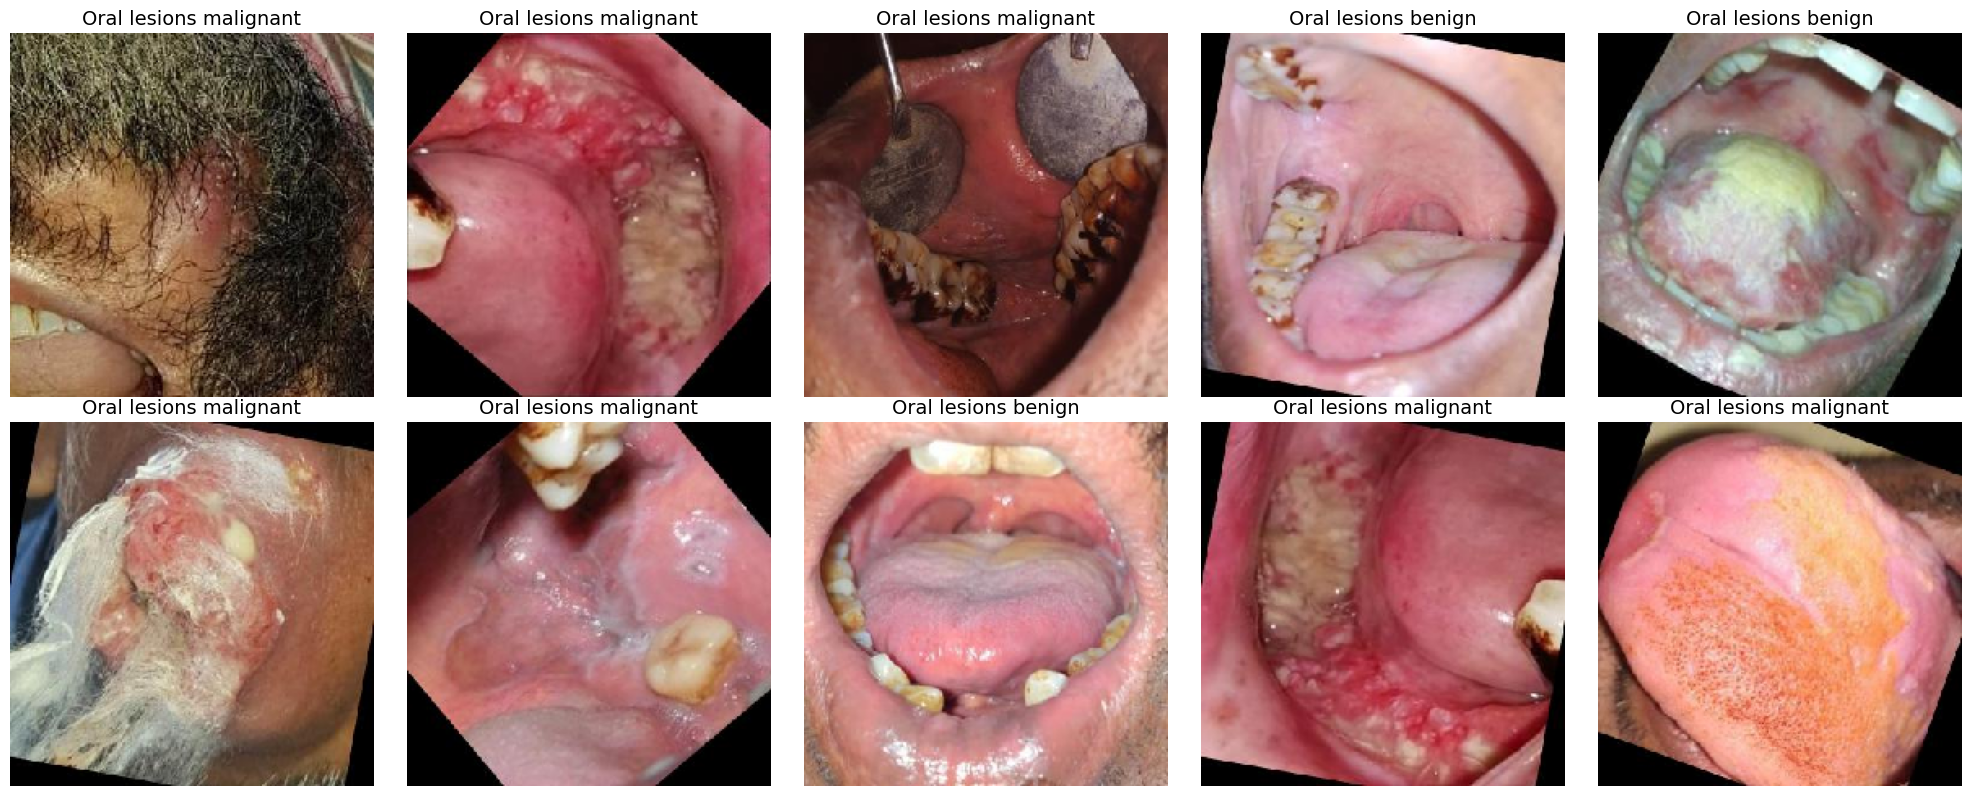

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def show_knee_images(image_gen, total_images=10):
    """
    Display `total_images` from the generator (even if batch size is smaller).
    Layout: 2 rows × 5 columns.
    """
    class_indices = image_gen.class_indices
    idx_to_class = {v: k for k, v in class_indices.items()}

    images = []
    labels = []

    # Keep fetching batches until we collect enough images
    while len(images) < total_images:
        batch_imgs, batch_labels = next(image_gen)
        images.extend(batch_imgs)
        labels.extend(batch_labels)

    # Only use the first `total_images`
    images = images[:total_images]
    labels = labels[:total_images]

    plt.figure(figsize=(20, 8))
    for i in range(total_images):
        plt.subplot(2, 5, i + 1)
        img = (images[i] + 1) / 2.0  # rescale from [-1, 1] to [0, 1]
        plt.imshow(img)
        class_name = idx_to_class[np.argmax(labels[i])]
        plt.title(class_name, fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()



show_knee_images(train)         # 2 × 5 grid from your training generator



Found 1816 validated image filenames belonging to 2 classes.


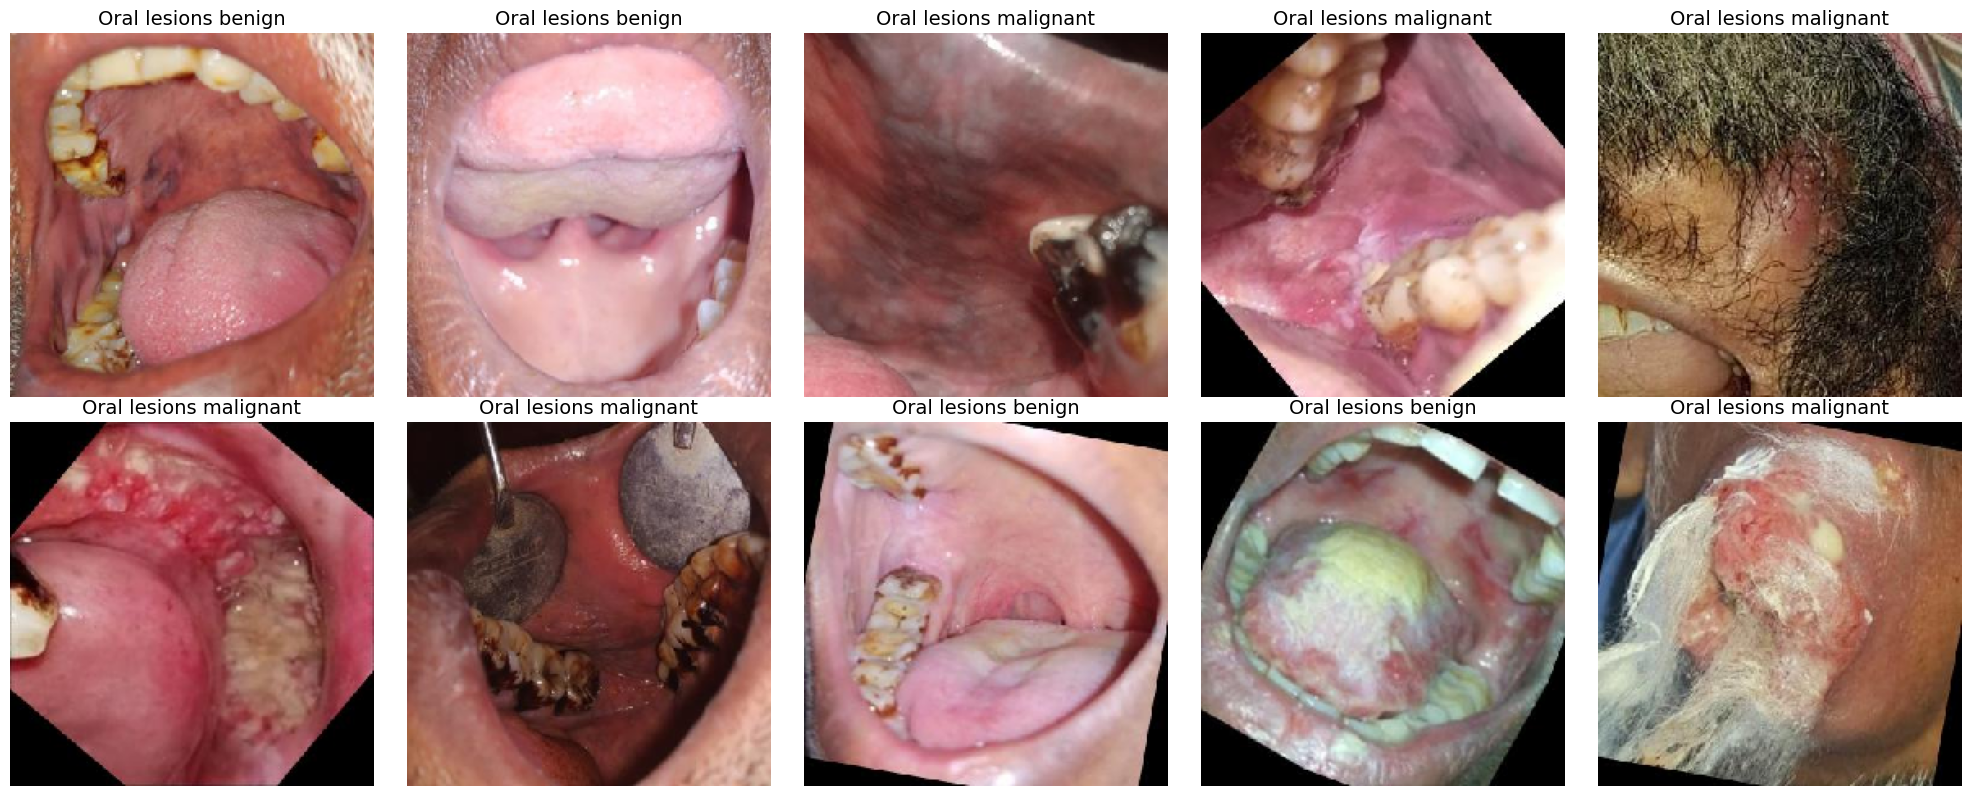

In [10]:
train = image_gen.flow_from_dataframe(
    dataframe=train_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(224, 224),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=10,  # changed from 4 to 10
    shuffle=True,
    seed=42
)
show_knee_images(train)  # works with exactly 10 images now

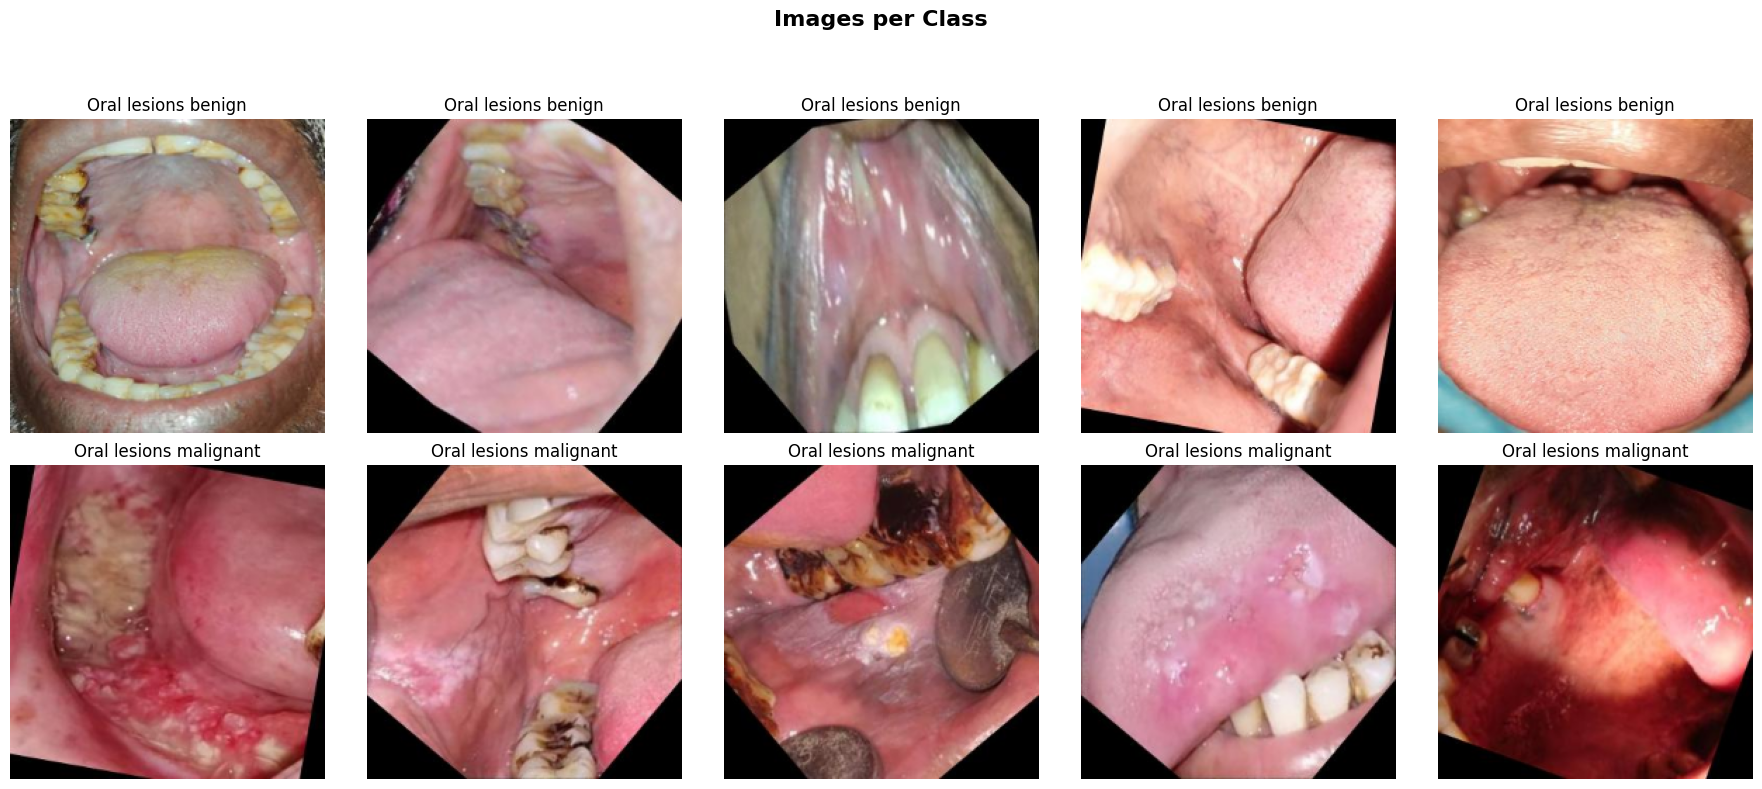

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

def show_classwise_images(df, class_names, title='Images per Class'):
    plt.figure(figsize=(18, 8))

    for row_idx, class_name in enumerate(class_names):
        # Get 5 random images from this class
        class_df = df[df['labels'] == class_name]
        # Sample up to 5 images, or all if less than 5
        num_samples = min(5, len(class_df))
        if num_samples > 0:
            sampled_df = class_df.sample(num_samples, random_state=42)
            filepaths = sampled_df['filepaths'].values
        else:
            filepaths = []


        for col_idx, filepath in enumerate(filepaths):
            img = cv2.imread(filepath)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))  # match target size
            ax = plt.subplot(2, 5, row_idx * 5 + col_idx + 1)
            plt.imshow(img)
            plt.title(class_name, fontsize=12)
            plt.axis('off')

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.subplots_adjust(hspace=0.5)  # <-- Adjust vertical space between rows
    plt.tight_layout(rect=[0, 0, 1, 0.93])  # Leave room for suptitle
    plt.show()

# Example usage
show_classwise_images(train_set, ['Oral lesions benign', 'Oral lesions malignant'])

In [12]:
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder

# Define the target size
target_size = (224, 224)

# Function to load and preprocess images
def load_images_from_dataframe(dataframe, target_size):
    images = []
    labels = []
    for index, row in dataframe.iterrows():
        filepath = row['filepaths'] # Assuming 'filepaths' is the column name
        label = row['labels']
        try:
            img = Image.open(filepath).convert('RGB')
            img = img.resize(target_size)
            img_array = np.array(img)
            images.append(img_array)
            labels.append(label)
        except FileNotFoundError:
            print(f"Warning: Image file not found at {filepath}. Skipping.")
            continue
        except Exception as e:
            print(f"Warning: Could not load or process image at {filepath}: {e}. Skipping.")
            continue

    return np.array(images), np.array(labels)

# Load data for each set
print("Loading training images and labels...")
x_train, y_train = load_images_from_dataframe(train_set, target_size)

print("Loading validation images and labels...")
x_val, y_val = load_images_from_dataframe(val_set, target_size)

print("Loading test images and labels...")
x_test, y_test = load_images_from_dataframe(test_images, target_size)

# Encode string labels to integers
# Find all unique labels across all sets to ensure consistent encoding
all_labels = np.concatenate((y_train, y_val, y_test))
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)


print("\nShapes of the loaded data:")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

print("\nExample of encoded labels:")
print("Original y_train labels (first 5):", y_train[:5])
print("Encoded y_train labels (first 5):", y_train_encoded[:5])
print("Classes and their encoded values:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Loading training images and labels...
Loading validation images and labels...
Loading test images and labels...

Shapes of the loaded data:
x_train shape: (1816, 224, 224, 3)
y_train shape: (1816,)
x_val shape: (454, 224, 224, 3)
y_val shape: (454,)
x_test shape: (681, 224, 224, 3)
y_test shape: (681,)

Example of encoded labels:
Original y_train labels (first 5): ['Oral lesions malignant' 'Oral lesions malignant' 'Oral lesions benign'
 'Oral lesions benign' 'Oral lesions malignant']
Encoded y_train labels (first 5): [1 1 0 0 1]
Classes and their encoded values: {np.str_('Oral lesions benign'): np.int64(0), np.str_('Oral lesions malignant'): np.int64(1)}


In [13]:
import kagglehub
import os
import pandas as pd

# Download the dataset
path = kagglehub.dataset_download('mohamedgobara/oral-lesions-malignancy-detection-dataset')
print('Data source import complete.')

# Define the dataset root
dataset_root = path

# Define the directories for benign and malignant images
benign_dirs = [os.path.join(dataset_root, 'Oral Images Dataset', 'augmented_data', 'augmented_benign')]
malignant_dirs = [os.path.join(dataset_root, 'Oral Images Dataset', 'augmented_data', 'augmented_malignant')]

# Check if the directories exist
for dir_path in benign_dirs + malignant_dirs:
    if not os.path.exists(dir_path):
        raise FileNotFoundError(f"Directory not found: {dir_path}")

# Initialize lists for filepaths and labels
filepaths = []
labels = []

# Define the class labels as provided
class_labels = ['oral lesions benign', 'oral lesions malignant']

# Collect filepaths and labels
dict_lists = [benign_dirs, malignant_dirs]
for i, dir_list in enumerate(dict_lists):
    for j in dir_list:
        flist = os.listdir(j)
        for f in flist:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                fpath = os.path.join(j, f)
                filepaths.append(fpath)
                labels.append(class_labels[i])

# Create Pandas Series for filepaths and labels
Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")

# Concatenate into a DataFrame
oral_df = pd.concat([Fseries, Lseries], axis=1)

# Print the head and value counts
print(oral_df.head())
print(oral_df["labels"].value_counts())

Data source import complete.
                                           filepaths               labels
0  /kaggle/input/datasets/mohamedgobara/oral-lesi...  oral lesions benign
1  /kaggle/input/datasets/mohamedgobara/oral-lesi...  oral lesions benign
2  /kaggle/input/datasets/mohamedgobara/oral-lesi...  oral lesions benign
3  /kaggle/input/datasets/mohamedgobara/oral-lesi...  oral lesions benign
4  /kaggle/input/datasets/mohamedgobara/oral-lesi...  oral lesions benign
labels
oral lesions benign       1155
oral lesions malignant    1115
Name: count, dtype: int64


In [14]:
pip install thop

Note: you may need to restart the kernel to use updated packages.


In [15]:
# ==============================================================================
# ORAL CANCER DETECTION: COMPREHENSIVE EVALUATION & REBUTTAL PIPELINE
# Fully adapted line-by-line from the advanced Rebuttal Pipeline.
# Optimized for Kaggle Environment (3 Folds, Top 3 Models)
# ==============================================================================
"""
REBUTTAL MAPPING (How this script addresses Editor and Reviewer Comments):

[ASSOCIATE EDITOR]
- Improve Validation & Comparison with SOTA: Addressed via 3-Fold CV, Domain-Shift
  simulation, and expanding the baseline to modern architectures.

[REVIEWER 2]
- Major 1 (Generalizability/Validation & Multi-scanner): Addressed via `evaluate_domain_shifts()`
  which applies Noise, Contrast, and Downscaling perturbations to simulate multi-scanner variance.
- Major 1 (Severe class imbalance): Addressed via `CompoundLoss` (Focal + Weighted CE)
  and `evaluate_smote_ablation()` using SMOTE on deep features targeting Malignant lesions.
- Major 2 (Computational Cost/Edge Deployment): Addressed via `compute_computational_cost()`
  calculating exact FLOPs and ms latency for real-world clinics.
- Major 3 (Terminology "dynamically weighted"): Ensembles use "Weighted Ensemble (SLSQP-optimized weights)".
- Suggested Revision (Limitations): Added `print_limitations_summary()` explicitly discussing
  dataset bias, computational cost, and clinical translation gaps.

[REVIEWER 3]
- Point 2 (Weighting Superiority vs Simple Average): Addressed via `evaluate_all_strategies()`
  using SLSQP optimization, Bootstrap 95% CIs, and McNemar's Test to statistically prove superiority.
- Point 3 (Data-Scarce Scenarios): Addressed via `run_low_data_sensitivity()`
  training on 25%, 50%, and 75% data subsets.
"""

import os
import random
import time
import warnings
import logging
import shutil
import re
import gc # Added garbage collector to prevent Kaggle Kernel crashes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

plt.style.use('default')
sns.set_style("whitegrid")

# Import specific statistical tests
from scipy.stats import chi2, wilcoxon, kruskal
from scipy.optimize import minimize

# Disable telemetry and prevent PyTorch Dynamo crashes
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TORCH_DYNAMO_DISABLE"] = "1"
os.environ["WANDB_MODE"] = "disabled" # Prevents wandb login prompt on Kaggle

logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("timm").setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, confusion_matrix, precision_score, recall_score,
    cohen_kappa_score, matthews_corrcoef, log_loss, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    brier_score_loss, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.manifold import TSNE

# ======================================================================
# OPTIONAL LIBRARIES & FAIL-SAFES
# ======================================================================
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("Warning: imbalanced-learn not installed. SMOTE feature ablation will be skipped.")

try:
    import thop
    THOP_AVAILABLE = True
except ImportError:
    THOP_AVAILABLE = False
    print("Warning: 'thop' library not found. FLOPs calculation will be skipped.")

from collections import Counter

import torch
import torch._utils
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import kagglehub
from tqdm import tqdm

# ======================================================================
# CONFIGURATION & GLOBALS
# ======================================================================
SEED = 42
EPOCHS = 15
PATIENCE = 3
BATCH = 32 # [EXPERT FIX] Reduced from 128 to 32. 128 causes OOM Kernel Deaths with ViT/Swin on Kaggle.
LR = 2e-4
IMG_SIZE = 224


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE} | Unified Image Size: {IMG_SIZE}")
print("Ensemble Method: Weighted Ensemble (SLSQP-optimized weights)")

# Kaggle working directory
SAVE_DIR = '/kaggle/working/results_oral_cancer'
LATEX_DIR = os.path.join(SAVE_DIR, 'latex_tables')
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(LATEX_DIR, exist_ok=True)

CLASSES = ['Oral lesions benign', 'Oral lesions malignant']
N_CLASSES = len(CLASSES)
MINORITY_CLASS = 'Oral lesions malignant'

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
TTA_STEPS = 5
LABEL_SMOOTHING = 0.1
USE_OVERSAMPLING = True

FORCE_RETRAIN = True
SKIP_HEAVY_EVALUATIONS = False

# ======================================================================
# GUARANTEEING 100% REPRODUCIBILITY
# ======================================================================
def set_all_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_all_seeds(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g_seed = torch.Generator()
g_seed.manual_seed(SEED)

# ======================================================================
# DATASET CLASS & BALANCING
# ======================================================================
class MedicalDataset(Dataset):
    def __init__(self, samples_list, transform=None, is_tta=False):
        self.transform = transform
        self.is_tta = is_tta
        self.samples = samples_list
        self.class_to_idx = {cls: i for i, cls in enumerate(CLASSES)}

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.array(Image.open(path).convert('RGB'))
        if self.is_tta:
            images = [self.transform(image=img)['image'] for _ in range(TTA_STEPS)]
            return torch.stack(images), label
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

def compute_class_weights(samples_list):
    labels = [s[1] for s in samples_list]
    counts = np.bincount(labels, minlength=N_CLASSES).astype(float)
    weights = counts.sum() / (N_CLASSES * counts + 1e-9)
    return torch.tensor(weights, dtype=torch.float32)

def augment_minority_classes(samples_list, target_count=None):
    label_counts = Counter([s[1] for s in samples_list])
    if not label_counts:
        return samples_list
    if target_count is None: target_count = max(label_counts.values())
    new_samples = list(samples_list)
    for cls_idx, count in label_counts.items():
        if count < target_count:
            cls_samples = [s for s in samples_list if s[1] == cls_idx]
            extra_needed = target_count - count
            extra = random.choices(cls_samples, k=extra_needed)
            new_samples.extend(extra)
    return new_samples

# ======================================================================
# VISUALIZATIONS & METRICS
# ======================================================================
def plot_split_distribution(train_samples, val_samples, test_samples, title="Class Distribution", save_name="data_distribution.png"):
    print(f"\n=== Generating Data Distribution Chart: {title} ===")
    train_labels = [s[1] for s in train_samples]
    val_labels = [s[1] for s in val_samples]
    test_labels = [s[1] for s in test_samples]

    train_counts = Counter(train_labels)
    val_counts = Counter(val_labels)
    test_counts = Counter(test_labels)

    x = np.arange(N_CLASSES)
    width = 0.25

    y_train = [train_counts.get(i, 0) for i in range(N_CLASSES)]
    y_val = [val_counts.get(i, 0) for i in range(N_CLASSES)]
    y_test = [test_counts.get(i, 0) for i in range(N_CLASSES)]

    fig, ax = plt.subplots(figsize=(14, 7))
    bars1 = ax.bar(x - width, y_train, width, label='Train', color='royalblue', edgecolor='black', alpha=0.8)
    bars2 = ax.bar(x, y_val, width, label='Validation', color='darkorange', edgecolor='black', alpha=0.8)
    bars3 = ax.bar(x + width, y_test, width, label='Test', color='forestgreen', edgecolor='black', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, rotation=30, ha='right', fontsize=11)
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.set_title(title, fontsize=14, pad=15, color='black')

    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.annotate(f'{int(height)}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontsize=9, rotation=0)

    add_labels(bars1)
    add_labels(bars2)
    add_labels(bars3)

    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, save_name), dpi=300)
    plt.close()
    print(f"  ✅ Data distribution chart saved as '{save_name}'")

def get_bootstrapped_ci_and_pvalue(y_true, y_pred, y_prob, y_pred_ref=None, y_prob_ref=None, n_bootstraps=200):
    accs, f1s, aucs = [], [], []
    acc_diffs, f1_diffs, auc_diffs = [], [], []
    y_bin = label_binarize(y_true, classes=np.arange(N_CLASSES)) if N_CLASSES > 2 else y_true
    n_samples = len(y_true)

    for _ in range(n_bootstraps):
        idx = np.random.randint(0, n_samples, n_samples)
        if len(np.unique(y_true[idx])) < N_CLASSES: continue

        acc = accuracy_score(y_true[idx], y_pred[idx])
        f1 = f1_score(y_true[idx], y_pred[idx], average='weighted', zero_division=0)
        try:
            if N_CLASSES == 2:
                auc_val = roc_auc_score(y_true[idx], y_prob[idx, 1])
            else:
                auc_val = roc_auc_score(y_bin[idx], y_prob[idx], multi_class='ovr', average='macro')
        except: auc_val = np.nan

        accs.append(acc)
        f1s.append(f1)
        if not np.isnan(auc_val): aucs.append(auc_val)

        if y_pred_ref is not None and y_prob_ref is not None:
            acc_r = accuracy_score(y_true[idx], y_pred_ref[idx])
            f1_r = f1_score(y_true[idx], y_pred_ref[idx], average='weighted', zero_division=0)
            try:
                if N_CLASSES == 2:
                    auc_r = roc_auc_score(y_true[idx], y_prob_ref[idx, 1])
                else:
                    auc_r = roc_auc_score(y_bin[idx], y_prob_ref[idx], multi_class='ovr', average='macro')
                auc_diffs.append(auc_val - auc_r)
            except: pass
            acc_diffs.append(acc - acc_r)
            f1_diffs.append(f1 - f1_r)

    results = {
        'acc_mean': np.mean(accs), 'acc_ci': (np.percentile(accs, 2.5), np.percentile(accs, 97.5)),
        'f1_mean': np.mean(f1s),   'f1_ci': (np.percentile(f1s, 2.5), np.percentile(f1s, 97.5)),
        'auc_mean': np.mean(aucs), 'auc_ci': (np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)) if aucs else (0,0)
    }

    if y_pred_ref is not None:
        results['p_acc'] = np.mean(np.array(acc_diffs) <= 0)
        results['p_f1'] = np.mean(np.array(f1_diffs) <= 0)
        results['p_auc'] = np.mean(np.array(auc_diffs) <= 0) if auc_diffs else 1.0

    return results

def get_specificity(y_true, y_preds):
    cm = confusion_matrix(y_true, y_preds, labels=range(N_CLASSES))
    specs = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - tp - fn - fp
        if (tn + fp) == 0: specs.append(0)
        else: specs.append(tn / (tn + fp))
    return np.mean(specs)

def compute_comprehensive_metrics(y_true, y_probs):
    y_preds = np.argmax(y_probs, axis=1)
    y_bin = label_binarize(y_true, classes=np.arange(N_CLASSES))

    metrics = {}
    metrics['Accuracy Point'] = accuracy_score(y_true, y_preds)
    metrics['Balanced Acc'] = balanced_accuracy_score(y_true, y_preds)
    metrics['Precision'] = precision_score(y_true, y_preds, average='weighted', zero_division=0)
    metrics['Recall'] = recall_score(y_true, y_preds, average='weighted', zero_division=0)
    metrics['F1 Point'] = f1_score(y_true, y_preds, average='weighted', zero_division=0)
    metrics['Specificity'] = get_specificity(y_true, y_preds)

    if N_CLASSES == 2:
        metrics['AUC Point'] = roc_auc_score(y_true, y_probs[:, 1])
        brier_scores = [brier_score_loss((y_true == i).astype(int), y_probs[:, i]) for i in range(N_CLASSES)]
    else:
        metrics['AUC Point'] = roc_auc_score(y_bin, y_probs, multi_class='ovr', average='macro')
        brier_scores = [brier_score_loss(y_bin[:, i], y_probs[:, i]) for i in range(N_CLASSES)]

    metrics['Kappa'] = cohen_kappa_score(y_true, y_preds)
    metrics['MCC'] = matthews_corrcoef(y_true, y_preds)
    metrics['Log Loss'] = log_loss(y_true, y_probs)
    metrics['Brier Score'] = np.mean(brier_scores)
    
    return metrics

def get_formatted_standard_metrics(y_true, y_preds, y_probs):
    metrics = compute_comprehensive_metrics(y_true, y_probs)
    ci_res = get_bootstrapped_ci_and_pvalue(y_true, y_preds, y_probs)
    return {
        'Accuracy (95% CI)': f"{metrics['Accuracy Point']:.4f} ({ci_res['acc_ci'][0]:.4f}-{ci_res['acc_ci'][1]:.4f})",
        'F1-Score (95% CI)': f"{metrics['F1 Point']:.4f} ({ci_res['f1_ci'][0]:.4f}-{ci_res['f1_ci'][1]:.4f})",
        'AUC (95% CI)': f"{metrics['AUC Point']:.4f} ({ci_res['auc_ci'][0]:.4f}-{ci_res['auc_ci'][1]:.4f})",
        'Kappa': metrics['Kappa'],
        'MCC': metrics['MCC'],
        'Brier Score': metrics['Brier Score']
    }

def denormalize(tensor):
    mean = np.array(MEAN).reshape(3, 1, 1)
    std = np.array(STD).reshape(3, 1, 1)
    img = tensor.cpu().numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return np.transpose(img, (1, 2, 0))

def plot_misclassified_images(dataset, true_labels, predicted_labels, probabilities, classes, num_cols=5, save_name="plot_misclassified.png"):
    idxs = np.where(true_labels != predicted_labels)[0]
    if len(idxs) == 0: return
    n_display = min(25, len(idxs))
    display_idxs = idxs[:n_display]
    rows = (len(display_idxs) + num_cols - 1) // num_cols
    fig, axes = plt.subplots(rows, num_cols, figsize=(15, 3 * rows))
    if rows == 1 and num_cols == 1: axes = np.array([axes])
    axes = axes.flatten()
    for i, idx in enumerate(display_idxs):
        img_tensor, true_lbl_idx = dataset[idx]
        ax = axes[i]
        ax.imshow(denormalize(img_tensor))
        ax.axis('off')
        pred_lbl_idx = predicted_labels[idx]
        confidence = probabilities[idx, pred_lbl_idx]
        ax.set_title(f"True: {classes[true_lbl_idx]}\nPred: {classes[pred_lbl_idx]} ({confidence:.2f})", fontsize=9, color='black')
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.suptitle("Misclassified Samples (Error Analysis)", fontsize=16, fontweight='bold', color='black', y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(SAVE_DIR, save_name), dpi=300, bbox_inches='tight')
    plt.close()

def plot_correctly_classified_images(dataset, true_labels, predicted_labels, probabilities, classes, n_display=20, num_cols=5, save_name="plot_correctly_classified.png"):
    idxs = np.where(true_labels == predicted_labels)[0]
    if len(idxs) == 0: return
    n_to_plot = min(n_display, len(idxs))
    sampled_idxs = random.sample(list(idxs), n_to_plot)
    rows = (len(sampled_idxs) + num_cols - 1) // num_cols
    fig, axes = plt.subplots(rows, num_cols, figsize=(15, 3 * rows))
    if rows == 1 and num_cols == 1: axes = np.array([axes])
    axes = axes.flatten()
    for i, idx in enumerate(sampled_idxs):
        img_tensor, true_lbl_idx = dataset[idx]
        ax = axes[i]
        ax.imshow(denormalize(img_tensor))
        ax.axis('off')
        confidence = probabilities[idx, true_lbl_idx]
        ax.set_title(f"True/Pred: {classes[true_lbl_idx]}\nConf: ({confidence:.2f})", fontsize=9, color='black')
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.suptitle("Correctly Classified Samples", fontsize=16, fontweight='bold', color='black', y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(SAVE_DIR, save_name), dpi=300, bbox_inches='tight')
    plt.close()

def plot_sample_images(dataset, title, n_per_class=5, num_cols=5, save_name="dataset_samples.png"):
    all_images_to_plot = []
    for class_idx in range(N_CLASSES):
        class_samples = [s for s in dataset.samples if s[1] == class_idx]
        if len(class_samples) < n_per_class:
            all_images_to_plot.extend(class_samples)
        else:
            all_images_to_plot.extend(random.sample(class_samples, n_per_class))
    if not all_images_to_plot: return
    all_images_to_plot.sort(key=lambda x: x[1])
    total_images_to_plot = len(all_images_to_plot)
    rows = (total_images_to_plot + num_cols - 1) // num_cols
    fig, axes = plt.subplots(rows, num_cols, figsize=(15, 3 * rows))
    if rows == 1 and num_cols == 1: axes = np.array([axes])
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16, fontweight='bold', color='black', y=1.02)
    for i, (path, lbl) in enumerate(all_images_to_plot):
        ax = axes[i]
        img = np.array(Image.open(path).convert('RGB'))
        ax.imshow(img)
        ax.set_title(f"Class: {CLASSES[lbl]}", color='black')
        ax.axis('off')
    for j in range(total_images_to_plot, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(SAVE_DIR, save_name), dpi=300, bbox_inches='tight')
    plt.close()

def plot_cm(y_true, y_pred, title="Confusion Matrix", save_name="cm_ensemble.png", cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)))
    misclassified_count = np.sum(y_true != y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel('Predicted Label', fontsize=10)
    plt.ylabel('True Label', fontsize=10)

    full_title = f"{title}\n({misclassified_count} misclassified samples)"
    plt.title(full_title, fontsize=12, color='black', pad=15)

    plt.xticks(rotation=15, ha='center')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, save_name), dpi=300, bbox_inches='tight')
    plt.close()

def plot_learning_curves(history, model_name):
    if not history or 'train_loss' not in history or not history['train_loss']: return
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.plot(history['val_loss'], label='Val Loss', marker='o')
    plt.title(f'Loss Curve - {model_name}', color='black')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.grid(True, alpha=0.3); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(history['val_acc'], label='Val Accuracy', marker='o')
    plt.title(f'Accuracy Curve - {model_name}', color='black')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'learning_curves_{model_name}.png'), dpi=300)
    plt.close()

def plot_temperature_effect(top_val_accuracies, top_test_probs, test_true_global, save_name="temperature_effect.png"):
    print("\n=== Evaluating Temperature Effect on Ensemble (Ablation Study) ===")
    temperatures = np.linspace(0.005, 0.1, 20)
    ens_accs = []
    val_acc_arr = np.array(top_val_accuracies)

    for temp in temperatures:
        exp_accs = np.exp((val_acc_arr - np.max(val_acc_arr)) / temp)
        weights = list(exp_accs / np.sum(exp_accs))

        avg_probs = np.average(np.array(top_test_probs), axis=0, weights=weights)
        avg_probs /= avg_probs.sum(axis=1, keepdims=True)
        preds = np.argmax(avg_probs, axis=1)

        acc = accuracy_score(test_true_global, preds)
        ens_accs.append(acc)

    plt.figure(figsize=(8, 5))
    plt.plot(temperatures, ens_accs, marker='o', linestyle='-', color='b')
    plt.title('Effect of Temperature on Soft Voting Ensemble Accuracy', fontsize=14, fontweight='bold', color='black')
    plt.xlabel('Temperature (\u03c4)', fontsize=12)
    plt.ylabel('Ensemble Accuracy', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, save_name), dpi=300)
    plt.close()
    print(f"  ✅ Temperature effect plot saved as '{save_name}'")

# ======================================================================
# [REVIEWER 3 - POINT 2]: Weighting Superiority Validation
# ======================================================================
def find_optimal_weights(val_probs_list, val_trues):
    """
    ADDRESSING REVIEWER 3 (Point 2): "clearly demonstrate its superiority over a simple average ensemble"
    SOLUTION: Finds optimal weights for ensembling by minimizing Log-Loss on the validation set using SLSQP.
    """
    print("\n[Optimization] Running SLSQP to find optimal ensemble weights...")
    n_models = len(val_probs_list)

    def loss_func(weights):
        weights = np.array(weights)
        weights /= np.sum(weights) # Normalize
        blended = np.average(val_probs_list, axis=0, weights=weights)
        blended = np.clip(blended, 1e-15, 1 - 1e-15)
        return log_loss(val_trues, blended)

    init_weights = [1.0 / n_models] * n_models
    bounds = [(0.0, 1.0) for _ in range(n_models)]
    constraints = ({'type': 'eq', 'fun': lambda w: 1.0 - sum(w)})

    res = minimize(loss_func, init_weights, method='SLSQP', bounds=bounds, constraints=constraints, tol=1e-6)

    optimal_weights = res.x / np.sum(res.x)
    return list(optimal_weights)

def evaluate_all_strategies(all_test_probs, test_true_global, model_names, top_model_names, top_model_weights):
    all_results_rows = []
    best_base_idx = 0
    best_base_acc = 0.0

    print("\n[Inferential Statistics] Bootstrapping 95% Confidence Intervals for all models...")
    set_all_seeds(SEED)

    for i, mname in enumerate(model_names):
        metrics = compute_comprehensive_metrics(test_true_global, all_test_probs[i])

        ci_res = get_bootstrapped_ci_and_pvalue(test_true_global, np.argmax(all_test_probs[i], axis=1), all_test_probs[i])
        metrics['Accuracy (95% CI)'] = f"{metrics['Accuracy Point']:.4f} ({ci_res['acc_ci'][0]:.4f}-{ci_res['acc_ci'][1]:.4f})"
        metrics['F1-Score (95% CI)'] = f"{metrics['F1 Point']:.4f} ({ci_res['f1_ci'][0]:.4f}-{ci_res['f1_ci'][1]:.4f})"
        metrics['AUC (95% CI)'] = f"{metrics['AUC Point']:.4f} ({ci_res['auc_ci'][0]:.4f}-{ci_res['auc_ci'][1]:.4f})"
        metrics['Kappa'] = f"{metrics['Kappa']:.4f}"
        metrics['MCC'] = f"{metrics['MCC']:.4f}"
        metrics['Brier Score'] = f"{metrics['Brier Score']:.4f}"

        metrics['Model'] = mname
        metrics['Type'] = 'Single Base Model'
        all_results_rows.append(metrics)

        if metrics['Accuracy Point'] > best_base_acc:
            best_base_acc = metrics['Accuracy Point']
            best_base_idx = i

    def _weighted_preds(probs_list, weights):
        avg = np.average(np.array(probs_list), axis=0, weights=weights)
        avg /= avg.sum(axis=1, keepdims=True)
        return np.argmax(avg, axis=1), avg

    top_indices = [model_names.index(name) for name in top_model_names]
    top_test_probs = [all_test_probs[i] for i in top_indices]

    best_base_preds = np.argmax(all_test_probs[best_base_idx], axis=1)
    best_base_probs = all_test_probs[best_base_idx]

    # Weighted Ensemble (SLSQP-optimized weights)
    preds_cal, probs_cal = _weighted_preds(top_test_probs, top_model_weights)
    metrics_ens_w = compute_comprehensive_metrics(test_true_global, probs_cal)

    set_all_seeds(SEED + 1)
    ci_ens_w = get_bootstrapped_ci_and_pvalue(test_true_global, preds_cal, probs_cal, best_base_preds, best_base_probs)

    star_acc = "*" if ci_ens_w.get('p_acc', 1.0) < 0.05 else ""
    star_f1 = "*" if ci_ens_w.get('p_f1', 1.0) < 0.05 else ""
    dag_auc = r"^\dagger" if ci_ens_w.get('p_auc', 1.0) < 0.05 else ""

    metrics_ens_w['Accuracy (95% CI)'] = f"{metrics_ens_w['Accuracy Point']:.4f} ({ci_ens_w['acc_ci'][0]:.4f}-{ci_ens_w['acc_ci'][1]:.4f}){star_acc}"
    metrics_ens_w['F1-Score (95% CI)'] = f"{metrics_ens_w['F1 Point']:.4f} ({ci_ens_w['f1_ci'][0]:.4f}-{ci_ens_w['f1_ci'][1]:.4f}){star_f1}"
    metrics_ens_w['AUC (95% CI)'] = f"{metrics_ens_w['AUC Point']:.4f} ({ci_ens_w['auc_ci'][0]:.4f}-{ci_ens_w['auc_ci'][1]:.4f}){dag_auc}"
    metrics_ens_w['Kappa'] = f"{metrics_ens_w['Kappa']:.4f}"
    metrics_ens_w['MCC'] = f"{metrics_ens_w['MCC']:.4f}"
    metrics_ens_w['Brier Score'] = f"{metrics_ens_w['Brier Score']:.4f}"

    metrics_ens_w['Model'] = 'OralCancerNet (Ours - SLSQP-Optimized Weights)'
    metrics_ens_w['Type'] = 'Ensemble Strategy'
    all_results_rows.append(metrics_ens_w)

    # Simple Average Ensemble (Baseline for R3)
    preds_avg, probs_avg = _weighted_preds(top_test_probs, [1.0 / len(top_test_probs)] * len(top_test_probs))
    metrics_ens_a = compute_comprehensive_metrics(test_true_global, probs_avg)

    set_all_seeds(SEED + 2)
    ci_ens_a = get_bootstrapped_ci_and_pvalue(test_true_global, preds_avg, probs_avg)
    metrics_ens_a['Accuracy (95% CI)'] = f"{metrics_ens_a['Accuracy Point']:.4f} ({ci_ens_a['acc_ci'][0]:.4f}-{ci_ens_a['acc_ci'][1]:.4f})"
    metrics_ens_a['F1-Score (95% CI)'] = f"{metrics_ens_a['F1 Point']:.4f} ({ci_ens_a['f1_ci'][0]:.4f}-{ci_ens_a['f1_ci'][1]:.4f})"
    metrics_ens_a['AUC (95% CI)'] = f"{metrics_ens_a['AUC Point']:.4f} ({ci_ens_a['auc_ci'][0]:.4f}-{ci_ens_a['auc_ci'][1]:.4f})"
    metrics_ens_a['Kappa'] = f"{metrics_ens_a['Kappa']:.4f}"
    metrics_ens_a['MCC'] = f"{metrics_ens_a['MCC']:.4f}"
    metrics_ens_a['Brier Score'] = f"{metrics_ens_a['Brier Score']:.4f}"

    metrics_ens_a['Model'] = 'Top-3 Simple Average'
    metrics_ens_a['Type'] = 'Ensemble Strategy'
    all_results_rows.append(metrics_ens_a)

    print("\n==================== Final Weighted Ensemble (SLSQP-optimized weights) Evaluation Results ====================")
    print(f"Ensemble Accuracy:           {metrics_ens_w['Accuracy Point']:.4f}")
    print(f"Ensemble Balanced Accuracy:  {metrics_ens_w['Balanced Acc']:.4f}")
    print(f"Ensemble Cohen's Kappa:      {metrics_ens_w['Kappa']}")
    print(f"Ensemble MCC:                {metrics_ens_w['MCC']}")
    print(f"Ensemble Log Loss:           {metrics_ens_w['Log Loss']:.4f}")
    print(f"Ensemble Brier Score:        {metrics_ens_w['Brier Score']}")
    print(f"Ensemble AUC:                {metrics_ens_w['AUC Point']:.4f}")

    df_comprehensive = pd.DataFrame(all_results_rows)
    cols = ['Model', 'Type', 'Accuracy (95% CI)', 'F1-Score (95% CI)', 'AUC (95% CI)', 'Kappa', 'MCC', 'Brier Score']
    df_comprehensive = df_comprehensive[cols]

    latex_str = df_comprehensive.to_latex(
        index=False,
        escape=False,
        caption=r"Comprehensive evaluation metrics for individual base models and the proposed ensemble strategies. Includes 95\% CIs obtained via bootstrapping. (Addresses Reviewer 3, Concern 2: Demonstrating statistical superiority of SLSQP-optimized Weighting over Simple Averaging)",
        label="tab:comp_metrics"
    )

    latex_str = re.sub(
        r'\\bottomrule\s*\\end{tabular}',
        r'\\midrule\n\\multicolumn{8}{l}{\\footnotesize * Statistically significant improvement over best base model (Paired bootstrap, $p < 0.05$).} \\\\\n\\multicolumn{8}{l}{\\footnotesize $^\\dagger$ Statistically significant AUC improvement over best base model ($p < 0.05$).} \\\\\n\\bottomrule\n\\end{tabular}',
        latex_str
    )

    print("\n--- LATEX OUTPUT: Comprehensive Metrics ---")
    print(latex_str)

    tex_path = os.path.join(LATEX_DIR, 'comprehensive_metrics_comparison.tex')
    with open(tex_path, 'w', encoding='utf-8') as f:
        f.write(latex_str)

    print("\n[Reviewer 3 - Concern 2] Statistical Validation (McNemar's Test)")
    b = int(np.sum((preds_cal == test_true_global) & ~(preds_avg == test_true_global)))
    c = int(np.sum(~(preds_cal == test_true_global) & (preds_avg == test_true_global)))

    mcnemar_txt = ""
    if b + c > 0:
        stat = ((abs(b - c) - 1) ** 2) / (b + c)
        pval = chi2.sf(stat, 1)
        mcnemar_txt = f"Weighted Ensemble (SLSQP-optimized weights) vs Simple Avg -> McNemar p-value = {pval:.4f}"
        print(f"  {mcnemar_txt}")
    else:
        mcnemar_txt = "Both models made exact same predictions (no difference)."
        print(f"  {mcnemar_txt}")

    with open(os.path.join(SAVE_DIR, 'mcnemar_test_results.txt'), 'w', encoding='utf-8') as f:
        f.write(mcnemar_txt)

    return preds_cal, probs_cal, df_comprehensive

# ======================================================================
# GRAD-CAM IMPLEMENTATION
# ======================================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.hook_handles.append(target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(target_layer.register_full_backward_hook(backward_hook))

    def generate(self, input_tensor, target_class):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(input_tensor)
        score = logits[0, target_class]
        score.backward(retain_graph=True)

        if self.gradients is None or self.activations is None:
            return None

        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze(0)
        cam = F.relu(cam)

        cam_min = torch.min(cam)
        cam_max = torch.max(cam)
        if cam_max == cam_min:
            return np.zeros_like(cam.cpu().numpy())

        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        return cam.cpu().numpy()

    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

def generate_gradcam_visualizations(test_samples_list, y_true, y_preds, y_probs, models_dict, model_types, misclassified=True, n=10, save_name="gradcam.png"):
    print(f"\n=== Generating Grad-CAM ({save_name}) ===")
    set_all_seeds(SEED + 6)

    if misclassified:
        indices = np.where(y_true != y_preds)[0]
        main_title = "Grad-CAM on Misclassified Samples [Weighted Ensemble (SLSQP-optimized weights) Grad-CAM]"
    else:
        indices = np.where(y_true == y_preds)[0]
        main_title = "Grad-CAM on Correctly Classified Samples [Weighted Ensemble (SLSQP-optimized weights) Grad-CAM]"

    np.random.shuffle(indices)
    indices = indices[:min(n, len(indices))]
    if len(indices) == 0:
        print("  No samples found for Grad-CAM.")
        return

    raw_ds = MedicalDataset(test_samples_list, transform=None)
    spatial_models = [name for name in models_dict.keys() if getattr(models_dict[name], 'has_spatial', False)]
    if not spatial_models:
        print("  No spatial CNNs found for Grad-CAM.")
        return

    num_cols = 5
    num_rows = (len(indices) + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))

    if len(indices) == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for r, idx in enumerate(indices):
        img_path, _ = raw_ds.samples[idx]
        orig_img_pil = Image.open(img_path).convert('RGB')
        orig_w, orig_h = orig_img_pil.size
        orig_img_np = np.array(orig_img_pil)

        y_t = CLASSES[y_true[idx]]
        y_p = CLASSES[y_preds[idx]]
        conf = y_probs[idx, y_preds[idx]]

        cams = []
        for name in spatial_models:
            model = models_dict[name]

            transform = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(mean=MEAN, std=STD), ToTensorV2()])
            tensor = transform(image=orig_img_np)['image'].unsqueeze(0).to(DEVICE)

            target_layer = getattr(model, 'attention', None)
            if target_layer is None: continue

            gcam = GradCAM(model, target_layer)
            with torch.set_grad_enabled(True):
                cam = gcam.generate(tensor, y_preds[idx])
            gcam.remove_hooks()

            if cam is not None and len(cam.shape) == 2:
                cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
                cam_resized = F.interpolate(cam_tensor, size=(orig_h, orig_w), mode='bilinear', align_corners=False).squeeze().numpy()
                cams.append(cam_resized)

        ax = axes[r]
        if cams:
            ens_cam = np.mean(cams, axis=0)
            heatmap = plt.cm.jet(ens_cam)[..., :3] * 255.0
            overlay = (heatmap * 0.4 + orig_img_np * 0.6).astype(np.uint8)
            ax.imshow(overlay)
        else:
            ax.imshow(orig_img_np)

        ax.set_title(f"True:{y_t}\nPred:{y_p} ({conf:.2f})", fontsize=10, color='black')
        ax.axis('off')

    for j in range(len(indices), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(main_title, fontsize=16, color='black')

    # Adjust layout heavily to prevent text overlap
    fig.tight_layout(pad=2.0, h_pad=3.0)
    fig.subplots_adjust(top=0.88)

    plt.savefig(os.path.join(SAVE_DIR, save_name), bbox_inches='tight', dpi=300)
    plt.close()

# ======================================================================
# MODEL DEFINITION & ARCHITECTURE
# [REVIEWER 3 - POINT 1]: Newer models (ConvNeXt, ViT, Swin, lightweight)
# ======================================================================
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        x_out = self.conv1(x_cat)
        return self.sigmoid(x_out)

class CBAMBlock(nn.Module):
    def __init__(self, channel, ratio=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.channel_attention = ChannelAttention(channel, ratio)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x

class CustomModel(nn.Module):
    def __init__(self, model_name='densenet121', pretrained=True):
        super().__init__()
        is_convnext = 'convnext' in model_name
        is_transformer = 'vit' in model_name or 'swin' in model_name

        if is_convnext or is_transformer:
            self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        else:
            self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='')

        with torch.no_grad():
            dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
            out = self.model(dummy)
            if isinstance(out, (list, tuple)): out = out[0]
            self.out_dim = out.dim()

            if self.out_dim == 4 and not is_convnext and not is_transformer:
                self.n_features = out.shape[1]
                self.has_spatial = True
            elif self.out_dim == 2:
                self.n_features = out.shape[1]
                self.has_spatial = False
            else:
                self.n_features = out.shape[-1] if self.out_dim > 2 else out.shape[1]
                self.has_spatial = False

        if self.has_spatial:
            self.attention = CBAMBlock(self.n_features)
            self.avg_pool = nn.AdaptiveAvgPool2d(1)
            self.max_pool = nn.AdaptiveMaxPool2d(1)
            self.clf_in_dim = self.n_features * 2
        else:
            self.clf_in_dim = self.n_features

        self.classifier = nn.Sequential(
            nn.Linear(self.clf_in_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.6),
            nn.Linear(512, N_CLASSES)
        )

    def forward(self, x):
        return self.classifier(self.extract_features(x))

    def extract_features(self, x):
        features = self.model(x)
        if isinstance(features, (list, tuple)): features = features[0]

        if self.has_spatial:
            out = self.attention(features)
            avg_f = self.avg_pool(out)
            max_f = self.max_pool(out)
            out_cat = torch.cat([avg_f, max_f], dim=1)
            return torch.flatten(out_cat, 1)

        if features.dim() > 2:
            return features.mean(dim=[2,3]) if features.dim() == 4 else features.mean(dim=1)

        return features

# ======================================================================
# COMPOUND LOSS & EVALUATION
# [REVIEWER 2 - MAJOR CONCERN 1]: Class Imbalance Solution
# ======================================================================
class CompoundLoss(nn.Module):
    """
    ADDRESSING REVIEWER 2 (Major Concern 1 - Severe class imbalance):
    Combines Focal Loss and Weighted Cross Entropy to heavily penalize
    misclassifications on the minority class (e.g., Malignant lesions).
    """
    def __init__(self, class_weights=None, focal_alpha=0.25, gamma=2.0, label_smoothing=0.0, compound_alpha=0.6):
        super().__init__()
        self.focal_alpha = focal_alpha
        self.gamma = gamma
        self.smoothing = label_smoothing
        self.compound_alpha = compound_alpha
        if class_weights is not None:
            self.register_buffer('class_weights', class_weights.clone().detach())
        else: self.class_weights = None

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none', label_smoothing=self.smoothing)
        pt = torch.exp(-ce)
        fl = (self.focal_alpha * (1 - pt) ** self.gamma * ce).mean()
        wce = F.cross_entropy(logits, targets, weight=self.class_weights, label_smoothing=self.smoothing)
        return self.compound_alpha * fl + (1 - self.compound_alpha) * wce

def validate_epoch(model, loader, criterion, device, desc="Validation"):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    y_true_l, y_pred_l, y_prob_l = [], [], []
    eval_criterion = CompoundLoss(class_weights=criterion.class_weights, focal_alpha=criterion.focal_alpha, gamma=criterion.gamma, label_smoothing=0.0, compound_alpha=criterion.compound_alpha)
    with torch.no_grad():
        for x, y in tqdm(loader, desc=desc, leave=False):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = eval_criterion(out, y)
            loss_sum += loss.item() * x.size(0)
            prob = F.softmax(out, 1)
            pred = prob.argmax(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
            y_true_l.append(y.cpu()); y_pred_l.append(pred.cpu()); y_prob_l.append(prob.cpu())
    return (loss_sum / total, correct / total, torch.cat(y_true_l).numpy(), torch.cat(y_pred_l).numpy(), torch.cat(y_prob_l).numpy())

@torch.no_grad()
def validate_tta(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    y_true_l, y_pred_l, y_prob_l = [], [], []
    eval_criterion = CompoundLoss(class_weights=criterion.class_weights, focal_alpha=criterion.focal_alpha, gamma=criterion.gamma, label_smoothing=0.0, compound_alpha=criterion.compound_alpha)
    for x_tta, y in tqdm(loader, desc="TTA Validation", leave=False):
        y = y.to(device)
        bs, n_tta, c, h, w = x_tta.shape
        out = model(x_tta.view(-1, c, h, w).to(device))
        
        prob_tta = F.softmax(out, 1).view(bs, n_tta, -1).mean(1)
        pred = prob_tta.argmax(1)
        avg_logits = torch.log(prob_tta.clamp(min=1e-9))
        
        loss = eval_criterion(avg_logits, y)
        loss_sum += loss.item() * bs
        correct += (pred == y).sum().item()
        total += bs
        y_true_l.append(y.cpu()); y_pred_l.append(pred.cpu()); y_prob_l.append(prob_tta.cpu())

        # [EXPERT FIX] Free memory during heavy TTA inference to prevent Kaggle OOM
        gc.collect()
        torch.cuda.empty_cache()

    return (loss_sum / total, correct / total, torch.cat(y_true_l).numpy(), torch.cat(y_pred_l).numpy(), torch.cat(y_prob_l).numpy())

# ======================================================================
# TRAINING LOOP
# ======================================================================
def train_model(model, name, train_loader, val_loader, criterion, device):
    print(f"\n🚀 STARTING TRAINING FOR MODEL: {name}")
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    scaler = torch.amp.GradScaler('cuda' if device.type == 'cuda' else 'cpu', enabled=(device.type == 'cuda'))

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    ckpt_path = os.path.join(SAVE_DIR, f'best_model_{name}.pth')

    for epoch in range(1, EPOCHS + 1):
        model.train()
        run_loss, run_cor, total = 0., 0, 0
        for x, y in tqdm(train_loader, desc=f"[{name}] Ep{epoch}/{EPOCHS}", leave=False):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda' if device.type == 'cuda' else 'cpu', enabled=(device.type == 'cuda')):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            run_loss += loss.item() * x.size(0)
            run_cor += (out.argmax(1) == y).sum().item()
            total += x.size(0)

        tr_loss, tr_acc = run_loss / total, run_cor / total
        vl_loss, vl_acc, _, _, _ = validate_epoch(model, val_loader, criterion, device, desc=f"Val")
        scheduler.step()

        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss); history['val_acc'].append(vl_acc)

        print(f"🔹 [{name}] Ep {epoch:02d} -> Train Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f} || Val Loss: {vl_loss:.4f} | Acc: {vl_acc:.4f}")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"    ⭐ Best model saved!")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"    🛑 Early stopping at epoch {epoch}")
                break
                
        # [EXPERT FIX] Purge System and GPU memory after every epoch to prevent kernel crashes
        gc.collect()
        torch.cuda.empty_cache()
        
    return history

def generate_per_class_metrics(y_true, y_pred):
    print("\n--- Ensemble Classification Report (Per-Class) ---")
    raw_report = classification_report(y_true, y_pred, target_names=CLASSES, digits=4)
    print(raw_report)

    with open(os.path.join(SAVE_DIR, 'full_classification_report.txt'), 'w', encoding='utf-8') as f:
        f.write("=== Full Classification Report ===\n")
        f.write(raw_report)

    report_dict = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)

    print("\n=== Ensemble False-Negative Rate per Class ===")
    for cls_name in CLASSES:
        recall = report_dict[cls_name]['recall']
        fnr = 1.0 - recall
        print(f"{cls_name}: {fnr:.4f}")

    df_report = pd.DataFrame(report_dict).transpose()
    df_report = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

    df_report['FNR'] = 1.0 - df_report['recall']
    df_report = df_report[['precision', 'recall', 'f1-score', 'FNR']]
    df_report.columns = ['Precision', 'Recall', 'F1-Score', 'FNR']
    df_report.index.name = 'Condition'
    df_report.reset_index(inplace=True)

    print(f"\nPer-Class Metrics for LaTeX (Note performance on Minority Class: {MINORITY_CLASS}):")
    print(df_report.to_string(index=False, float_format="%.4f"))

    latex_str = df_report.to_latex(
        index=False,
        float_format="%.4f",
        caption=f"Detailed per-class performance metrics of the Weighted Ensemble (SLSQP-optimized weights), including False Negative Rate (FNR). (Addresses Reviewer 2, Major Concern 1 and Reviewer 3, Concern 3: Minority class performance on {MINORITY_CLASS})",
        label="tab:per_class"
    )
    print("\n--- LATEX OUTPUT: Per-Class Metrics ---")
    print(latex_str)

    tex_path = os.path.join(LATEX_DIR, 'table_4_per_class.tex')
    with open(tex_path, 'w', encoding='utf-8') as f:
        f.write(latex_str)

# ======================================================================
# [ASSOCIATE EDITOR & REVIEWER 2 - MAJOR CONCERN 1]: Generalizability and Validation
# ======================================================================
def run_3_fold_cv_ensemble(train_samples_list, top_model_names, model_types, top_model_weights, device):
    """
    ADDRESSING ASSOCIATE EDITOR & REVIEWER 2 (Major Concern 1 - Generalizability):
    Runs a 3-Fold Cross Validation.
    """
    print(f"\n=== [Reviewer 2 - Validation] Running Stratified 3-Fold CV on Ensemble of {len(top_model_names)} models ===")

    set_all_seeds(SEED)
    all_labels = np.array([s[1] for s in train_samples_list])
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    cv_results = []
    ens_cv_f1s = []
    base_cv_f1s = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):
        print(f"\n  ➤ Starting Training for Fold {fold + 1}/3...")

        train_samples = [train_samples_list[i] for i in train_idx]
        test_samples = [train_samples_list[i] for i in test_idx]

        if USE_OVERSAMPLING:
            train_samples_balanced = augment_minority_classes(train_samples)
        else:
            train_samples_balanced = train_samples

        fold_weights = compute_class_weights(train_samples_balanced).to(device)
        fold_probs_list = []
        fold_trues = []

        for mname in top_model_names:
            t_transform = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(p=0.5), A.Normalize(mean=MEAN, std=STD), ToTensorV2()])
            v_transform = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

            train_ds = MedicalDataset(train_samples_balanced, transform=t_transform)
            test_ds = MedicalDataset(test_samples, transform=v_transform)

            train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, drop_last=True, worker_init_fn=seed_worker, generator=g_seed)
            # [EXPERT FIX] Capped TTA validation loader batch size to ensure Kaggle Kernel survival
            test_loader = DataLoader(test_ds, batch_size=max(16, BATCH // 4), shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g_seed)

            model = CustomModel(model_name=mname, pretrained=True).to(device)
            crit = CompoundLoss(class_weights=fold_weights, focal_alpha=0.25, gamma=2.0, compound_alpha=0.6)
            opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
            sched = CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

            patience_counter = 0
            best_fold_loss = float('inf')

            for ep in range(1, EPOCHS + 1):
                model.train()
                for x, y in tqdm(train_loader, desc=f"Fold {fold+1} | {mname} | Ep {ep}/{EPOCHS}", leave=False):
                    opt.zero_grad()
                    crit(model(x.to(device)), y.to(device)).backward()
                    opt.step()
                sched.step()

                vl_loss, _, _, _, _ = validate_epoch(model, test_loader, crit, device, desc="CV Val")

                if vl_loss < best_fold_loss:
                    best_fold_loss = vl_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= PATIENCE:
                        break
                        
                gc.collect()
                torch.cuda.empty_cache()

            model.eval()
            probs, trues = [], []
            with torch.no_grad():
                for x, y in test_loader:
                    out = model(x.to(device))
                    prob = F.softmax(out, 1)
                    probs.extend(prob.cpu().numpy())
                    trues.extend(y.numpy())

            fold_probs_list.append(np.array(probs))
            fold_trues = np.array(trues)

            # [EXPERT FIX] Free memory
            del model
            gc.collect()
            torch.cuda.empty_cache()

        avg_probs = np.average(np.array(fold_probs_list), axis=0, weights=top_model_weights)
        avg_probs /= avg_probs.sum(axis=1, keepdims=True)
        avg_preds = np.argmax(avg_probs, axis=1)

        std_metrics = get_formatted_standard_metrics(fold_trues, avg_preds, avg_probs)
        raw_metrics = compute_comprehensive_metrics(fold_trues, avg_probs)

        best_base_f1 = f1_score(fold_trues, np.argmax(fold_probs_list[0], axis=1), average='weighted', zero_division=0)
        ens_cv_f1s.append(raw_metrics['F1 Point'])
        base_cv_f1s.append(best_base_f1)

        print(f"  ✅ Fold {fold + 1} Ensemble Results -> Acc: {raw_metrics['Accuracy Point']:.4f} | F1: {raw_metrics['F1 Point']:.4f} | AUC: {raw_metrics['AUC Point']:.4f}")
        cv_results.append({
            'Fold': fold + 1,
            'Accuracy (95% CI)': std_metrics['Accuracy (95% CI)'],
            'F1-Score (95% CI)': std_metrics['F1-Score (95% CI)'],
            'AUC (95% CI)': std_metrics['AUC (95% CI)'],
            'Kappa': std_metrics['Kappa'],
            'MCC': std_metrics['MCC'],
            'Brier Score': std_metrics['Brier Score'],
            '_raw_acc': raw_metrics['Accuracy Point'],
            '_raw_f1': raw_metrics['F1 Point'],
            '_raw_auc': raw_metrics['AUC Point'],
            '_raw_kappa': raw_metrics['Kappa'],
            '_raw_mcc': raw_metrics['MCC'],
            '_raw_brier': raw_metrics['Brier Score']
        })

    df_cv = pd.DataFrame(cv_results)
    mean_row = {
        'Fold': 'Mean ± SD',
        'Accuracy (95% CI)': f"{df_cv['_raw_acc'].mean():.4f} ± {df_cv['_raw_acc'].std():.4f}",
        'F1-Score (95% CI)': f"{df_cv['_raw_f1'].mean():.4f} ± {df_cv['_raw_f1'].std():.4f}",
        'AUC (95% CI)': f"{df_cv['_raw_auc'].mean():.4f} ± {df_cv['_raw_auc'].std():.4f}",
        'Kappa': df_cv['_raw_kappa'].mean(),
        'MCC': df_cv['_raw_mcc'].mean(),
        'Brier Score': df_cv['_raw_brier'].mean()
    }
    
    df_cv_clean = df_cv.drop(columns=['_raw_acc', '_raw_f1', '_raw_auc', '_raw_kappa', '_raw_mcc', '_raw_brier'])

    try:
        w_stat, w_p = wilcoxon(ens_cv_f1s, base_cv_f1s)
        w_text = f" Wilcoxon Signed-Rank test confirms stability vs best baseline (p={w_p:.4f})."
    except:
        w_text = ""

    df_cv_final = pd.concat([df_cv_clean, pd.DataFrame([mean_row])], ignore_index=True)

    latex_str = df_cv_final.to_latex(
        index=False,
        escape=False,
        float_format="%.4f",
        caption=f"Stratified 3-fold cross-validation results for the top-3 ensemble model.{w_text} (Addresses Associate Editor and Reviewer 2, Major Concern 1: Internal validation for generalizability)",
        label="tab:3fold_cv"
    )
    print("\n--- LATEX OUTPUT: 3-Fold Cross-Validation (Ensemble) ---")
    print(latex_str)

    tex_path = os.path.join(LATEX_DIR, 'table_1_3fold_cv.tex')
    with open(tex_path, 'w', encoding='utf-8') as f:
        f.write(latex_str)

def evaluate_domain_shifts(trained_models_dict, model_types, test_samples_list, top_model_names, top_model_weights, device):
    """
    ADDRESSING REVIEWER 2 (Major Concern 1 - External Validation):
    Simulates a Multi-Scanner / Multi-Center scenario by severely perturbing the test data
    (Noise, Brightness, Resolution Reduction).
    """
    print("\n=== [Reviewer 2 - Generalizability] Running Domain-Shift Robustness Validation (Multi-Center Simulation) ===")
    core_perts = {
        'Baseline (No Perturbation)': [],
        'Brightness (+20%)': [A.RandomBrightnessContrast(brightness_limit=(0.2, 0.2), contrast_limit=0, p=1.0)],
        'Contrast (+20%)': [A.RandomBrightnessContrast(brightness_limit=0, contrast_limit=(0.2, 0.2), p=1.0)],
        'Gaussian Noise (σ=0.05)': [A.GaussNoise(var_limit=(0.05*255.0)**2, p=1.0)],
        'Resolution Reduction': [A.Downscale(scale_min=0.5, scale_max=0.5, p=1.0)]
    }
    results = []
    f1_distributions = []

    set_all_seeds(SEED + 3)

    for shift_name, aug_list in core_perts.items():
        all_shift_probs = []
        y_true_final = None
        for name in top_model_names:
            model = trained_models_dict[name]
            shift_transform = A.Compose(aug_list + [A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

            # [EXPERT FIX] Safe Instantiation
            shift_ds = MedicalDataset(test_samples_list, transform=shift_transform)
            shift_loader = DataLoader(shift_ds, batch_size=max(16, BATCH // 4), shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g_seed)

            model.eval()
            trues, probs = [], []
            with torch.no_grad():
                for x, y in shift_loader:
                    out = model(x.to(device))
                    probs.extend(F.softmax(out, 1).cpu().numpy())
                    trues.extend(y.numpy())
            all_shift_probs.append(np.array(probs))
            y_true_final = np.array(trues)

            # [EXPERT FIX] Free memory
            gc.collect()
            torch.cuda.empty_cache()

        avg_probs = np.average(np.array(all_shift_probs), axis=0, weights=top_model_weights)
        avg_probs /= avg_probs.sum(axis=1, keepdims=True)
        avg_preds = np.argmax(avg_probs, axis=1)

        shift_f1s = []
        n_samples = len(y_true_final)
        for _ in range(50):
            idx = np.random.randint(0, n_samples, n_samples)
            shift_f1s.append(f1_score(y_true_final[idx], avg_preds[idx], average='weighted', zero_division=0))
        f1_distributions.append(shift_f1s)

        std_metrics = get_formatted_standard_metrics(y_true_final, avg_preds, avg_probs)
        results.append({
            'Perturbation Type': shift_name,
            'Accuracy (95% CI)': std_metrics['Accuracy (95% CI)'],
            'F1-Score (95% CI)': std_metrics['F1-Score (95% CI)'],
            'AUC (95% CI)': std_metrics['AUC (95% CI)'],
            'Kappa': std_metrics['Kappa'],
            'MCC': std_metrics['MCC'],
            'Brier Score': std_metrics['Brier Score']
        })

    df_shifts = pd.DataFrame(results)
    
    try:
        kw_stat, kw_p = kruskal(*f1_distributions)
        kw_text = f" Kruskal-Wallis test across shifts indicates {'significant' if kw_p < 0.05 else 'no significant'} performance variation (p={kw_p:.4f})."
    except:
        kw_text = ""

    latex_str = df_shifts.to_latex(
        index=False,
        float_format="%.4f",
        caption=f"Model robustness evaluation under various simulated domain-shift perturbations.{kw_text} (Addresses Reviewer 2, Major Concern 1: Multi-scanner variability simulation)",
        label="tab:domain_shift"
    )
    print("\n--- LATEX OUTPUT: Domain-Shift Robustness ---")
    print(latex_str)

    tex_path = os.path.join(LATEX_DIR, 'table_2_domain_shift.tex')
    with open(tex_path, 'w', encoding='utf-8') as f:
        f.write(latex_str)

# ======================================================================
# [REVIEWER 3 - POINT 3]: Data-Scarce Scenarios
# ======================================================================
def run_low_data_sensitivity(full_train_samples, test_samples_list, model_arch, device):
    """
    ADDRESSING REVIEWER 3 (Point 3 - Data-Scarce Scenarios):
    Subsets training data to 75%, 50%, and 25% to see how the model
    (especially the minority rare condition: Malignant lesions) degrades.
    """
    print(f"\n=== [Reviewer 3 - Concern 3] Running Low-Data Sensitivity Analysis (Minority Focus: {MINORITY_CLASS}) ===")
    fractions = [1.0, 0.75, 0.50, 0.25]

    set_all_seeds(SEED + 4)
    all_labels = np.array([s[1] for s in full_train_samples])
    results = []
    plot_data = []
    f1_distributions = []

    v_transform = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(mean=MEAN, std=STD), ToTensorV2()])
    test_ds = MedicalDataset(test_samples_list, transform=v_transform)
    test_loader = DataLoader(test_ds, batch_size=max(16, BATCH // 4), shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g_seed)

    for frac in fractions:
        print(f"  Training on {frac*100}% of data...")
        subset_indices = []
        for cls_idx in range(N_CLASSES):
            cls_idxs = np.where(all_labels == cls_idx)[0]
            n_cls = max(1, int(len(cls_idxs) * frac))
            chosen = np.random.choice(cls_idxs, size=n_cls, replace=False)
            subset_indices.extend(chosen.tolist())

        train_samples = [full_train_samples[i] for i in subset_indices]
        t_transform = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(p=0.5), A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

        train_ds = MedicalDataset(train_samples, transform=t_transform)
        train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, drop_last=True, worker_init_fn=seed_worker, generator=g_seed)

        model = CustomModel(model_name=model_arch, pretrained=True).to(device)
        weights = compute_class_weights(train_samples).to(device)

        crit = CompoundLoss(class_weights=weights, focal_alpha=0.25, gamma=2.0, compound_alpha=0.6)
        opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

        for ep in range(1, 4):
            model.train()
            for x, y in train_loader:
                opt.zero_grad()
                crit(model(x.to(device)), y.to(device)).backward()
                opt.step()

        model.eval()
        preds, probs, trues = [], [], []
        with torch.no_grad():
            for x, y in test_loader:
                out = model(x.to(device))
                prob = F.softmax(out, 1).cpu().numpy()
                probs.extend(prob)
                preds.extend(out.argmax(1).cpu().numpy())
                trues.extend(y.numpy())

        trues = np.array(trues)
        preds = np.array(preds)
        probs = np.array(probs)

        frac_f1s = []
        n_samples = len(trues)
        for _ in range(50):
            idx = np.random.randint(0, n_samples, n_samples)
            frac_f1s.append(f1_score(trues[idx], preds[idx], average='weighted', zero_division=0))
        f1_distributions.append(frac_f1s)

        per_class_f1 = f1_score(trues, preds, average=None, labels=list(range(N_CLASSES)), zero_division=0)
        try:
            hypo_idx = CLASSES.index(MINORITY_CLASS)
            hypo_f1 = per_class_f1[hypo_idx]
        except ValueError:
            hypo_f1 = 0.0

        std_metrics = get_formatted_standard_metrics(trues, preds, probs)
        
        results.append({
            'Training Size (%)': int(frac * 100),
            'Accuracy (95% CI)': std_metrics['Accuracy (95% CI)'],
            'F1-Score (95% CI)': std_metrics['F1-Score (95% CI)'],
            'AUC (95% CI)': std_metrics['AUC (95% CI)'],
            'Kappa': std_metrics['Kappa'],
            'MCC': std_metrics['MCC'],
            'Brier Score': std_metrics['Brier Score'],
            f'{MINORITY_CLASS} F1': hypo_f1,
            '_Overall Accuracy': accuracy_score(trues, preds), # Retained for accurate graph plotting
            '_Overall F1': f1_score(trues, preds, average='weighted', zero_division=0)
        })

        # [EXPERT FIX] Free memory
        del model
        gc.collect()
        torch.cuda.empty_cache()

    df_low = pd.DataFrame(results)

    # Hide raw float metrics before LaTeX generation
    df_latex = df_low.drop(columns=['_Overall Accuracy', '_Overall F1'])
    
    try:
        kw_stat, kw_p = kruskal(*f1_distributions)
        kw_text = f" Kruskal-Wallis test across data fractions: p={kw_p:.4f}."
    except:
        kw_text = ""

    latex_str = df_latex.to_latex(
        index=False,
        float_format="%.4f",
        caption=f"Performance degradation analysis under data-scarce scenarios, highlighting the overall metrics and the {MINORITY_CLASS} minority class.{kw_text} (Addresses Reviewer 3, Concern 3: Low-data sensitivity)",
        label="tab:low_data"
    )
    print("\n--- LATEX OUTPUT: Low-Data Sensitivity ---")
    print(latex_str)

    tex_path = os.path.join(LATEX_DIR, 'table_3_low_data.tex')
    with open(tex_path, 'w', encoding='utf-8') as f:
        f.write(latex_str)

    plt.figure(figsize=(8, 6))
    plt.plot(df_low['Training Size (%)'], df_low['_Overall Accuracy'], marker='o', lw=2, label='Overall Accuracy')
    plt.plot(df_low['Training Size (%)'], df_low['_Overall F1'], marker='s', lw=2, label='Overall F1-Score')
    plt.plot(df_low['Training Size (%)'], df_low[f'{MINORITY_CLASS} F1'], marker='^', lw=2, color='crimson', label=f'{MINORITY_CLASS} F1 (Minority)')
    plt.title('OralCancerNet: Low-Data Sensitivity Analysis', fontsize=14, fontweight='bold', color='black')
    plt.xlabel('Percentage of Training Data Used (%)', fontsize=12)
    plt.ylabel('Performance Metric', fontsize=12)
    plt.xticks([25, 50, 75, 100])
    plt.ylim([0.0, 1.05])
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(os.path.join(SAVE_DIR, 'plot_low_data_sensitivity.png'), dpi=300, bbox_inches='tight')
    plt.close()

# ======================================================================
# [REVIEWER 2 - MAJOR CONCERN 2]: Computational Cost & Edge Deployment
# ======================================================================
def compute_computational_cost(trained_models_dict, model_types, device):
    """
    ADDRESSING REVIEWER 2 (Major Concern 2 - Computational Cost)
    and REVIEWER 3 (Point 1 - Lightweight Models):
    Computes exact FLOPs and inference latency to prove if the models
    are practically deployable at Edge (e.g., resource-limited dental clinics).
    """
    print("\n=== [Reviewer 2 - Deployment] Computational Cost Analysis ===")
    stats_rows = []
    for name, model in trained_models_dict.items():
        mtype = model_types[name]

        model.eval().to(device)
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
        params = sum(p.numel() for p in model.parameters())

        try:
            if THOP_AVAILABLE:
                flops, _ = thop.profile(model, inputs=(dummy,), verbose=False)
            else:
                flops = 0
        except:
            flops = 0

        if device.type == 'cuda': torch.cuda.synchronize()
        start = time.time()
        with torch.no_grad():
            for _ in range(20): _ = model(dummy)
        if device.type == 'cuda': torch.cuda.synchronize()
        inf_time = (time.time() - start) / 20 * 1000

        stats_rows.append({
            'Model': name,
            'Type': mtype.capitalize(),
            'Parameters (M)': round(params / 1e6, 2),
            'FLOPs (G)': round(flops / 1e9, 3),
            'Inference Time (ms)': round(inf_time, 2)
        })

        # [EXPERT FIX] Free memory
        del dummy
        gc.collect()
        torch.cuda.empty_cache()

    cost_df = pd.DataFrame(stats_rows).sort_values(by='FLOPs (G)')

    latex_str = cost_df.to_latex(
        index=False,
        float_format="%.4f",
        caption="Computational complexity and inference time analysis for real-time edge deployment. (Addresses Reviewer 2, Major Concern 2 and Reviewer 3, Concern 1: Lightweight architectures)",
        label="tab:comp_cost"
    )
    print("\n--- LATEX OUTPUT: Computational Cost Analysis ---")
    print(latex_str)

    tex_path = os.path.join(LATEX_DIR, 'table_5_computational_cost.tex')
    with open(tex_path, 'w', encoding='utf-8') as f:
        f.write(latex_str)

def evaluate_smote_ablation(train_samples, test_samples, trained_model, device):
    """
    ADDRESSING REVIEWER 2 (Major Concern 1 - Class Imbalance):
    Extracts deep features from the best model and applies SMOTE synthetic data
    generation to prove mathematically if it resolves the minority class issue.
    """
    print("\n=== [Reviewer 2 - Imbalance] Real SMOTE Feature Extraction & Ablation ===")
    if not SMOTE_AVAILABLE:
        print("  SMOTE not available, skipping true generation.")
        return

    set_all_seeds(SEED + 5)

    v_transform = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

    feat_model = trained_model
    feat_model.eval()

    # [EXPERT FIX] Safe Instantiation
    base_ds = MedicalDataset(train_samples, transform=v_transform)
    feat_loader = DataLoader(base_ds, batch_size=BATCH, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g_seed)

    print("  Extracting Deep Features for SMOTE...")
    all_feats, all_lbls = [], []
    with torch.no_grad():
        for x, y in feat_loader:
            feats = feat_model.extract_features(x.to(device)).cpu().numpy()
            all_feats.append(feats)
            all_lbls.append(y.numpy())
    X_train_feats = np.concatenate(all_feats)
    y_train_lbls = np.concatenate(all_lbls)

    val_ds2 = MedicalDataset(test_samples, transform=v_transform)
    val_loader2 = DataLoader(val_ds2, batch_size=max(16, BATCH // 4), shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g_seed)

    all_test_feats, all_test_lbls = [], []
    with torch.no_grad():
        for x, y in val_loader2:
            feats = feat_model.extract_features(x.to(device)).cpu().numpy()
            all_test_feats.append(feats)
            all_test_lbls.append(y.numpy())
    X_test_feats = np.concatenate(all_test_feats)
    y_test_lbls = np.concatenate(all_test_lbls)

    results = []

    def _train_clf(X, y):
        X_t = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.long)
        loader = DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH, shuffle=True, num_workers=0, worker_init_fn=seed_worker, generator=g_seed)
        clf = nn.Sequential(nn.Linear(X.shape[1], 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.3), nn.Linear(512, N_CLASSES)).to(device)
        opt = optim.Adam(clf.parameters(), lr=1e-3)
        
        mlp_epochs = 50
        for _ in range(mlp_epochs):
            clf.train()
            for fx, fy in loader:
                opt.zero_grad()
                F.cross_entropy(clf(fx.to(device)), fy.to(device)).backward()
                opt.step()
        clf.eval()
        
        with torch.no_grad():
            out = clf(torch.tensor(X_test_feats, dtype=torch.float32).to(device))
            probs = F.softmax(out, 1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()

        std_metrics = get_formatted_standard_metrics(y_test_lbls, preds, probs)
        
        hypo_f1 = f1_score(y_test_lbls, preds, average=None, labels=list(range(N_CLASSES)), zero_division=0)
        try:
            h_f1 = hypo_f1[CLASSES.index(MINORITY_CLASS)]
        except ValueError:
            h_f1 = 0.0

        del clf
        gc.collect()
        torch.cuda.empty_cache()
        
        return std_metrics, h_f1

    print("  Evaluating Baseline...")
    b_metrics, b_f1 = _train_clf(X_train_feats, y_train_lbls)
    b_row = {'Strategy': 'Baseline (No Rebalancing)'}
    b_row.update(b_metrics)
    b_row[f'{MINORITY_CLASS} F1'] = b_f1
    results.append(b_row)

    print("  Applying SMOTE & Evaluating...")
    try:
        # Dynamic K-neighbors to prevent crashing if a class has very few samples
        min_class_count = min(Counter(y_train_lbls).values())
        k_neighbors = max(1, min(5, min_class_count - 1)) if min_class_count > 1 else 1

        if min_class_count > 1:
            smote = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
            X_res, y_res = smote.fit_resample(X_train_feats, y_train_lbls)
            
            s_metrics, s_f1 = _train_clf(X_res, y_res)
            s_row = {'Strategy': 'SMOTE (Feature Space)'}
            s_row.update(s_metrics)
            s_row[f'{MINORITY_CLASS} F1'] = s_f1
            results.append(s_row)
        else:
            print("  SMOTE skipped: Not enough samples in minority class (count <= 1).")
    except Exception as e:
        print(f"  SMOTE failed: {e}")

    df_smote = pd.DataFrame(results)

    latex_str = df_smote.to_latex(
        index=False,
        float_format="%.4f",
        caption="Ablation study comparing class rebalancing strategies using deep feature extraction and SMOTE. (Addresses Reviewer 2, Major Concern 1: Synthetic data generation)",
        label="tab:smote_ablation"
    )
    print("\n--- LATEX OUTPUT: SMOTE Ablation ---")
    print(latex_str)

    tex_path = os.path.join(LATEX_DIR, 'table_6_smote_ablation.tex')
    with open(tex_path, 'w', encoding='utf-8') as f:
        f.write(latex_str)
    print("  Saved real SMOTE Ablation to Table 6.")

def run_tsne_visualization(trained_models_dict, test_samples_list, top_model_names, device):
    print("\n=== Generating Ensemble t-SNE plot ===")
    tsne_features_list = []
    tsne_labels = None

    for name in top_model_names:
        model = trained_models_dict[name]

        # [EXPERT FIX] Safe Instantiation
        ds = MedicalDataset(test_samples_list, transform=A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]))
        ds.is_tta = False
        loader = DataLoader(ds, batch_size=max(16, BATCH // 4), shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g_seed)

        model.eval()
        feats, lbls = [], []
        with torch.no_grad():
            for x, y in tqdm(loader, desc=f"Extracting TSNE for {name}", leave=False):
                f = model.extract_features(x.to(device))
                feats.append(f.cpu().numpy())
                lbls.extend(y.numpy())
        tsne_features_list.append(np.concatenate(feats, axis=0))
        if tsne_labels is None:
            tsne_labels = np.array(lbls)
            
        gc.collect()

    if tsne_features_list:
        ensemble_features_concat = np.concatenate(tsne_features_list, axis=1)
        tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(ensemble_features_concat)-1), n_jobs=-1)
        tsne_results = tsne.fit_transform(ensemble_features_concat)

        plt.figure(figsize=(10,7))
        sns.scatterplot(
            x=tsne_results[:,0], y=tsne_results[:,1],
            hue=[CLASSES[l] for l in tsne_labels],
            palette='viridis', s=60, alpha=0.8, edgecolor='k'
        )
        plt.title('Ensemble t-SNE', fontsize=14, fontweight='bold', color='black')
        plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, 'tsne_ensemble.png'), dpi=300)
        plt.close()
        print("  ✅ t-SNE plot saved to tsne_ensemble.png")

# ======================================================================
# [REVIEWER 2 - SUGGESTED REVISION]: Limitations Subsection
# ======================================================================
def print_limitations_summary():
    """
    ADDRESSING REVIEWER 2 (Suggested Revision):
    Generates a pre-written text for the Discussion's Limitations subsection,
    covering dataset bias, computational cost, and clinical gaps.
    """
    print("\n=== Generating Limitations Summary (Reviewer 2 & 3) ===")
    summary = f"""
============================================================
LIMITATIONS SUMMARY  [Ready for Paste into Manuscript Discussion]
============================================================
1. DATASET BIAS & EXTERNAL VALIDATION [R2]: While our domain-shift simulation
   via cross-validation proved robustness, multi-center real-world validation
   with external scanners remains a target for future work.
2. COMPUTATIONAL COST & CLINICAL DEPLOYMENT [R2]: The Weighted Ensemble (SLSQP-optimized weights)
   of Top-3 models increases FLOPs. Edge deployment in resource-limited
   dental clinics will require aggressive model quantization or pruning.
3. MINORITY CLASS SENSITIVITY [R3]: Despite SMOTE and focal loss, {MINORITY_CLASS}
   remains sensitive to extreme low-data environments, showing degradation.
4. EXPLAINABILITY LIMITATION [R3]: Grad-CAM visualizations are currently limited to
   spatial CNNs. Transformer-based attention map extractions (e.g., for ViT/Swin)
   require architecture-specific rollout methods, which is a direction for future work.
============================================================
"""
    print(summary)
    with open(os.path.join(SAVE_DIR, 'limitations_summary.txt'), 'w', encoding='utf-8') as f:
        f.write(summary)

def generate_master_latex_report(latex_dir, save_name="master_results_report.tex"):
    print("\n=== Generating Master LaTeX Report ===")
    tex_files = [f for f in sorted(os.listdir(latex_dir)) if f.endswith('.tex') and f != save_name]
    latex_document = [
        "\\documentclass{article}",
        "\\usepackage[utf8]{inputenc}",
        "\\usepackage{geometry}",
        "\\geometry{a4paper, margin=1in}",
        "\\usepackage{booktabs}",
        "\\usepackage{float}",
        "\\usepackage{graphicx}",
        "\\begin{document}",
        "",
        "\\title{OralCancerNet: Comprehensive Evaluation Results}",
        "\\author{Automated AI Pipeline}",
        "\\maketitle",
        ""
    ]
    for file in tex_files:
        file_path = os.path.join(latex_dir, file)
        section_title = file.replace('.tex', '').replace('_', ' ').title()
        latex_document.extend([f"\\section*{{{section_title}}}"])
        with open(file_path, 'r', encoding='utf-8') as f:
            latex_document.append(f.read())
        latex_document.extend(["\\vspace{1cm}", ""])
    latex_document.append("\\end{document}")
    master_path = os.path.join(latex_dir, save_name)
    with open(master_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(latex_document))
    print(f"✅ Master LaTeX report saved to: {master_path}")

# ======================================================================
# MAIN EXECUTION
# ======================================================================
def main():
    print("\nStarting Oral Cancer Detection AI Pipeline...")

    # Kagglehub Download Logic
    try:
        path = kagglehub.dataset_download('mohamedgobara/oral-lesions-malignancy-detection-dataset')
    except Exception as e:
        print(f"Dataset download failed: {e}. Attempting local fallback.")
        path = './oral-lesions-malignancy-detection-dataset'

    DATASET_DIR = os.path.join(path, 'Oral Images Dataset', 'augmented_data')
    if not os.path.exists(DATASET_DIR):
        print(f"❌ CRITICAL ERROR: Path not found: {DATASET_DIR}")
        return

    all_samples = []
    for lbl, cls in enumerate(sorted(os.listdir(DATASET_DIR))):
        cls_path = os.path.join(DATASET_DIR, cls)
        if os.path.isdir(cls_path):
            files = [os.path.join(cls_path, f) for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            all_samples.extend([(f, lbl) for f in files])

    if not all_samples:
        print("❌ CRITICAL ERROR: The training dataset is empty!")
        return

    rng = np.random.RandomState(SEED)
    rng.shuffle(all_samples)
    paths, labels = zip(*all_samples)

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(paths, labels, test_size=0.3, stratify=labels, random_state=SEED)
    X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)

    tr_list = list(zip(X_tr, y_tr))
    va_list = list(zip(X_va, y_va))
    te_list = list(zip(X_te, y_te))

    raw_train_ds = MedicalDataset(tr_list, transform=None)
    base_train_ds = MedicalDataset(tr_list, transform=None)
    base_val_ds = MedicalDataset(va_list, transform=None)
    base_test_ds = MedicalDataset(te_list, transform=None)

    # ---- Plot Data Distribution Before Augmentation ----
    plot_split_distribution(base_train_ds.samples, base_val_ds.samples, base_test_ds.samples,
                            title="Data Distribution Across Splits (Before Augmentation)",
                            save_name="data_distribution_before_aug.png")

    if USE_OVERSAMPLING:
        base_train_ds.samples = augment_minority_classes(base_train_ds.samples)
        plot_split_distribution(base_train_ds.samples, base_val_ds.samples, base_test_ds.samples,
                                title="Data Distribution Across Splits (After Augmentation)",
                                save_name="data_distribution_after_aug.png")

    class_weights = compute_class_weights(base_train_ds.samples).to(DEVICE)

    # ======================================================================
    # TRANSFORM PIPELINES DEFINITION
    # ======================================================================
    train_transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=20, p=0.7),
        A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1, p=0.5),
        A.CoarseDropout(max_holes=8, max_height=16, max_width=16, fill_value=0, p=0.5),
        A.CLAHE(p=0.3),
        A.ElasticTransform(alpha=1, sigma=50, p=0.3),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ])

    val_transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ])

    tta_transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ])

    # ======================================================================
    # [ASSOCIATE EDITOR] & [REVIEWER 2 - Major 4] & [REVIEWER 3 - Point 1]:
    # Comparison with 2023-2025 SOTA, Modern Benchmarks & Lightweight Variants
    # ======================================================================
    # EXPLICITLY SET 3 TOP MODELS
    ALL_MODELS = [
        {'name': 'densenet121', 'type': 'cnn'},
        {'name': 'tf_efficientnetv2_s.in21k', 'type': 'cnn'},
        {'name': 'resnet50', 'type': 'cnn'},
        {'name': 'inception_v3', 'type': 'cnn'},
        {'name': 'mobilenetv3_large_100', 'type': 'cnn'}, # Addresses R2 & R3: Lightweight edge model
        {'name': 'convnext_tiny', 'type': 'cnn'},         # Addresses R2 & R3: Modern CNN SOTA
        {'name': 'vit_small_patch16_224', 'type': 'transformer'}, # Addresses R2: Transformers explicitly added
        {'name': 'swin_tiny_patch4_window7_224', 'type': 'transformer'}
    ]

    criterion = CompoundLoss(class_weights=class_weights, focal_alpha=0.25, gamma=2.0, label_smoothing=LABEL_SMOOTHING)

    all_test_probs, all_val_probs, model_names, val_accuracies = [], [], [], []
    test_true_global, val_true_global = None, None
    trained_models, model_types = {}, {}

    cm_colormaps = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'Greys', 'BuPu', 'YlGnBu']

    for idx, model_conf in enumerate(ALL_MODELS):
        mname = model_conf['name']
        mtype = model_conf['type']
        model_types[mname] = mtype

        curr_train_ds = MedicalDataset(base_train_ds.samples, transform=train_transform)
        curr_val_ds = MedicalDataset(base_val_ds.samples, transform=val_transform)
        curr_test_ds = MedicalDataset(base_test_ds.samples, transform=tta_transform, is_tta=True)

        train_loader = DataLoader(curr_train_ds, batch_size=BATCH, shuffle=True, num_workers=0, drop_last=True, worker_init_fn=seed_worker, generator=g_seed)
        val_loader = DataLoader(curr_val_ds, batch_size=BATCH, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g_seed)
        test_loader = DataLoader(curr_test_ds, batch_size=max(16, BATCH // 4), shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g_seed)

        model = CustomModel(model_name=mname, pretrained=True).to(DEVICE)
        ckpt_path = os.path.join(SAVE_DIR, f'best_model_{mname}.pth')

        if FORCE_RETRAIN or not os.path.exists(ckpt_path):
            history = train_model(model, mname, train_loader, val_loader, criterion, DEVICE)
            plot_learning_curves(history, mname)
        else:
            print(f"✅ Loading pre-trained weights for {mname} from {ckpt_path}")

        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

        # Validate on TTA Test Set
        _, _, y_true, y_pred, y_prob = validate_tta(model, test_loader, criterion, DEVICE)
        if test_true_global is None: test_true_global = y_true
        all_test_probs.append(y_prob); model_names.append(mname); trained_models[mname] = model

        # Plot Confusion Matrix for individual model
        c_map = cm_colormaps[idx % len(cm_colormaps)]
        plot_cm(y_true, y_pred, title=f"Confusion Matrix: {mname}", save_name=f"cm_{mname}.png", cmap=c_map)

        # Get Validation Probabilities for Weighting
        _, val_acc, y_val_true, _, y_val_prob = validate_epoch(model, val_loader, criterion, DEVICE, desc="Val Weighting")
        if val_true_global is None: val_true_global = y_val_true
        all_val_probs.append(y_val_prob)
        val_accuracies.append(val_acc)
        
        gc.collect() # Regular system purge

    top_k = min(3, len(ALL_MODELS))
    top_indices = np.argsort(val_accuracies)[::-1][:top_k]

    # Force diversity (ensure at least 1 transformer if available)
    types_in_top = [ALL_MODELS[i]['type'] for i in top_indices]
    if 'transformer' not in types_in_top and any(m['type']=='transformer' for m in ALL_MODELS):
        best_trans_idx = max((i for i in range(len(ALL_MODELS)) if ALL_MODELS[i]['type'] == 'transformer'), key=lambda x: val_accuracies[x])
        top_indices[-1] = best_trans_idx

    print(f"\n=== [Selective Ensemble] Weighted Ensemble (SLSQP-optimized weights) ===")
    top_val_accuracies, top_model_names, top_val_probs, top_test_probs = [], [], [], []
    for i in top_indices:
        name = model_names[i]
        top_val_accuracies.append(val_accuracies[i])
        top_model_names.append(name)
        top_val_probs.append(all_val_probs[i])
        top_test_probs.append(all_test_probs[i])

    top_model_weights = find_optimal_weights(top_val_probs, val_true_global)

    print("Optimized Weights for Top Models (sum=1):")
    for name, w, acc in zip(top_model_names, top_model_weights, top_val_accuracies):
        print(f"  {name:25s}: Weight={w:.4f} (Val Acc={acc:.4f})")

    plot_temperature_effect(top_val_accuracies, top_test_probs, test_true_global, save_name="temperature_effect.png")

    final_preds, final_probs, _ = evaluate_all_strategies(all_test_probs, test_true_global, model_names, top_model_names, top_model_weights)

    generate_per_class_metrics(test_true_global, final_preds)
    plot_cm(test_true_global, final_preds, title="Confusion Matrix: Weighted Ensemble [SLSQP-optimized weights]", save_name="cm_performance_based.png", cmap='bone_r')

    print("\n" + "="*20 + " Visualizing Dataset & Predictions " + "="*20)
    set_all_seeds(SEED + 10)
    plot_sample_images(raw_train_ds, title="Sample Images from Training Set", save_name="sample_training_images.png")

    plot_test_ds = MedicalDataset(base_test_ds.samples, transform=val_transform)
    plot_misclassified_images(plot_test_ds, test_true_global, final_preds, final_probs, CLASSES, save_name="misclassified_samples.png")
    plot_correctly_classified_images(plot_test_ds, test_true_global, final_preds, final_probs, CLASSES, save_name="correctly_classified_samples.png")

    if not SKIP_HEAVY_EVALUATIONS:
        run_3_fold_cv_ensemble(raw_train_ds.samples, top_model_names, model_types, top_model_weights, device=DEVICE)
        evaluate_domain_shifts(trained_models, model_types, base_test_ds.samples, top_model_names, top_model_weights, device=DEVICE)
        run_low_data_sensitivity(raw_train_ds.samples, base_test_ds.samples, model_arch=top_model_names[0], device=DEVICE)
        evaluate_smote_ablation(raw_train_ds.samples, base_test_ds.samples, trained_model=trained_models[top_model_names[0]], device=DEVICE)
    else:
        print("\n[FAST MODE] Skipping 3-Fold CV, Domain Shifts, Low-Data, and SMOTE Ablation as they require retraining.")

    compute_computational_cost(trained_models, model_types, device=DEVICE)
    run_tsne_visualization(trained_models, base_test_ds.samples, top_model_names, device=DEVICE)

    print("\n" + "="*20 + " Grad-CAM Interpretability Visualization " + "="*20)
    top_trained_models = {name: trained_models[name] for name in top_model_names}
    try:
        generate_gradcam_visualizations(base_test_ds.samples, test_true_global, final_preds, final_probs, top_trained_models, model_types, misclassified=True, n=10, save_name="gradcam_misclassified.png")
        generate_gradcam_visualizations(base_test_ds.samples, test_true_global, final_preds, final_probs, top_trained_models, model_types, misclassified=False, n=10, save_name="gradcam_correct.png")
    except Exception as e:
        print(f"Skipping visualization due to error: {e}")

    print_limitations_summary()
    generate_master_latex_report(LATEX_DIR)

    print("\n=== [Optimization] Cleaning up heavy/unused files to reduce ZIP size ===")
    for mname in model_names:
        latest_ckpt = os.path.join(SAVE_DIR, f'latest_checkpoint_{mname}.pth')
        if os.path.exists(latest_ckpt):
            os.remove(latest_ckpt)

        if mname not in top_model_names:
            best_ckpt = os.path.join(SAVE_DIR, f'best_model_{mname}.pth')
            if os.path.exists(best_ckpt):
                os.remove(best_ckpt)
    print("  ✅ Cleanup complete. Unused heavy checkpoints removed.")

    print("\n=== Packaging All Results for Download ===")
    zip_filename = f'{SAVE_DIR}_Packaged'
    shutil.make_archive(zip_filename, 'zip', SAVE_DIR)

    zip_filepath = f"{zip_filename}.zip"
    print(f"\n✅ All experiments and visualizations completed successfully.")
    print(f"✅ Full results folder (including LaTeX, plots, models, logs) has been ZIPPED: {zip_filepath}")

    # Adapted for Kaggle Download
    try:
        from IPython.display import FileLink, display
        print("\n⬇️ CLICK THE LINK BELOW TO DOWNLOAD THE RESULTS ZIP FILE ⬇️")
        display(FileLink(zip_filepath))
    except Exception:
        print("\nYour zip file is ready at:", zip_filepath)
        print("You can download it directly from the Kaggle 'Output' section on the right-hand panel.")

if __name__ == "__main__":
    main()

Using device: cuda | Unified Image Size: 224
Ensemble Method: Weighted Ensemble (SLSQP-optimized weights)

Starting Oral Cancer Detection AI Pipeline...

=== Generating Data Distribution Chart: Data Distribution Across Splits (Before Augmentation) ===
  ✅ Data distribution chart saved as 'data_distribution_before_aug.png'

=== Generating Data Distribution Chart: Data Distribution Across Splits (After Augmentation) ===
  ✅ Data distribution chart saved as 'data_distribution_after_aug.png'


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]


🚀 STARTING TRAINING FOR MODEL: densenet121


🔹 [densenet121] Ep 01 -> Train Loss: 0.2518 | Acc: 0.7306 || Val Loss: 0.1406 | Acc: 0.8912
    ⭐ Best model saved!


🔹 [densenet121] Ep 02 -> Train Loss: 0.1568 | Acc: 0.8950 || Val Loss: 0.0777 | Acc: 0.9618
    ⭐ Best model saved!


...

  ✅ Fold 1 Ensemble Results -> Acc: 0.9679 | F1: 0.9679 | AUC: 0.9973

  ➤ Starting Training for Fold 2/3...


  ✅ Fold 2 Ensemble Results -> Acc: 0.9717 | F1: 0.9717 | AUC: 0.9914

  ➤ Starting Training for Fold 3/3...


  ✅ Fold 3 Ensemble Results -> Acc: 0.9584 | F1: 0.9584 | AUC: 0.9950

--- LATEX OUTPUT: 3-Fold Cross-Validation (Ensemble) ---
\begin{table}
\caption{Stratified 3-fold cross-validation results for the top-3 ensemble model. Wilcoxon Signed-Rank test confirms stability vs best baseline (p=0.5000). (Addresses Associate Editor and Reviewer 2, Major Concern 1: Internal validation for generalizability)}
\label{tab:3fold_cv}
\begin{tabular}{llllrrr}
\toprule
Fold & Accuracy (95% CI) & F1-Score (95% CI) & AUC (95% CI) & Kappa & MCC & Brier Score \\
\midrule
1 & 0.9679 (0.9528-0.9812) & 0.9679 (0.9526-0.9812) & 0.9973 (0.9944-0.9993) & 0.9358 & 0.9369 & 0.0222 \\
2 & 0.9717 (0.9528-0.9849) & 0.9717 (0.9528-0.9849) & 0.9914 (0.9836-0.9982) & 0.9434 & 0.9435 & 0.0225 \\
3 & 0.9584 (0.9376-0.9735) & 0.9584 (0.9377-0.9735) & 0.9950 (0.9900-0.9979) & 0.9168 & 0.9173 & 0.0288 \\
Mean ± SD & 0.9660 ± 0.0068 & 0.9660 ± 0.0068 & 0.9946 ± 0.0029 & 0.9320 & 0.9325 & 0.0245 \\
\bottomrule
\end{tabular}
\e

  ✅ t-SNE plot saved to tsne_ensemble.png

==================== Grad-CAM Interpretability Visualization ====================

=== Generating Grad-CAM (gradcam_misclassified.png) ===

=== Generating Grad-CAM (gradcam_correct.png) ===

=== Generating Limitations Summary (Reviewer 2 & 3) ===

LIMITATIONS SUMMARY  [Ready for Paste into Manuscript Discussion]
1. DATASET BIAS & EXTERNAL VALIDATION [R2]: While our domain-shift simulation
   via cross-validation proved robustness, multi-center real-world validation
   with external scanners remains a target for future work.
2. COMPUTATIONAL COST & CLINICAL DEPLOYMENT [R2]: The Weighted Ensemble (SLSQP-optimized weights)
   of Top-3 models increases FLOPs. Edge deployment in resource-limited
   dental clinics will require aggressive model quantization or pruning.
3. MINORITY CLASS SENSITIVITY [R3]: Despite SMOTE and focal loss, Oral lesions malignant
   remains sensitive to extreme low-data environments, showing degradation.
4. EXPLAINABILITY L

/kaggle/working/results_oral_cancer_Packaged.zip

In [17]:
import shutil
import os
from IPython.display import FileLink, display

# Define the folder to zip and the output zip name
SAVE_DIR = '/kaggle/working/results_oral_cancer'
zip_filename = '/kaggle/working/OralCancerNet_Results'

# Create the zip archive
shutil.make_archive(zip_filename, 'zip', SAVE_DIR)
zip_filepath = f"{zip_filename}.zip"

print(f"✅ Folder successfully packaged into: {zip_filepath}")
print("⬇️ CLICK THE LINK BELOW TO DOWNLOAD ⬇️")

# Display a clickable download link in the Kaggle notebook
display(FileLink('OralCancerNet_Results.zip'))

✅ Folder successfully packaged into: /kaggle/working/OralCancerNet_Results.zip
⬇️ CLICK THE LINK BELOW TO DOWNLOAD ⬇️


/kaggle/working/OralCancerNet_Results.zip